## Figure 3 — Transmon / Schrödinger equivalence in the narrow-pass-band regime

This notebook reproduces **Figure 3** of the paper.

In the narrow-pass-band limit ($\eta = C_1/|C_0| > 1$), the Mathieu eigenvalue problem
governing Bloch wave propagation is mathematically identical to the stationary
Schrödinger equation of the **Transmon qubit**:
$$-4E_C\,\frac{d^2\psi}{d\varphi^2} - E_J\cos\varphi\,\psi = \mathcal{E}\,\psi$$
The notebook demonstrates this equivalence numerically by comparing eigenvalues
and eigenfunctions from both formulations.


In [1]:
import numpy as np
import scipy.special as sp
from scipy.sparse import diags
from scipy.optimize import fsolve
from scipy.sparse.linalg import eigs
from scipy.linalg import eigh
from scipy.special import mathieu_a, mathieu_cem, mathieu_b, mathieu_sem
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
from scipy.stats import linregress
from numpy import linalg as LA
import scipy.linalg
import cmath as cm
import matplotlib.pyplot as plt

In [2]:
def equation_lin(t, y, toto, titi):  
    qq, pp  = y
    #dydt = [pp, -(toto-2*titi*np.cos(2*t))*qq]
    dydt = [pp, -(toto+2*titi*np.cos(2*(t-np.pi/2)))*qq]
    return dydt


In [3]:
def find(element, vector):
    
    """ Function returning index of an element in a vector """
    
    for i in range(len(vector)):
        if vector[i] == element:
            return (i)

In [4]:
def compute_energy(fft_wave, k):
    # Compute the squared amplitude of the FFT (energy density in Fourier space)
    amplitude_squared = np.abs(fft_wave)**2
    
    # Compute the spacing in k-space (assumes uniform sampling in k)
    dk = np.abs(k[1] - k[0])  # Assumes k is sorted and evenly spaced
    
    # Integrate energy density over all wavenumbers
    total_energy = np.sum(amplitude_squared) * dk
    
    return total_energy

In [5]:
def sol_comp_mode_floquet(t, y, a, q, sn):
    JJ = np.array([ [0.,1 ],
                       [-(a+2*q*np.cos(2*(t-np.pi/2))),0.] ],dtype=complex)
    Is = np.array([ [sn,0.],
                       [0.,sn] ],dtype=complex)
    mat_B   = JJ - Is 
    dydt    = np.dot(mat_B,y)
    return dydt



In [6]:
from scipy.signal import find_peaks

def find_fft_peaks(fft_wave_shifted, k, height=None, distance=None):
    """
    Find the peaks of the FFT and their corresponding wavenumbers.
    
    Parameters:
    - fft_wave_shifted (np.ndarray): The shifted FFT amplitude array.
    - k (np.ndarray): The wavenumbers corresponding to the FFT.
    - height (float, optional): Minimum amplitude for a peak. Default is None.
    - distance (int, optional): Minimum distance between peaks in indices. Default is None.
    
    Returns:
    - peak_k (np.ndarray): Wavenumbers corresponding to the peaks.
    - peak_amplitudes (np.ndarray): Amplitudes of the peaks.
    """
    # Find peaks in the FFT amplitude
    peaks, _ = find_peaks(np.abs(fft_wave_shifted), height=height, distance=distance)
    
    # Extract wavenumbers and amplitudes at the peaks
    peak_k = k[peaks]
    peak_amplitudes = np.abs(fft_wave_shifted[peaks])
    
    # Return unique peaks sorted by wavenumber
    unique_indices = np.argsort(peak_k)
    return peak_k[unique_indices], peak_amplitudes[unique_indices]

In [7]:
def compute_hill_eigenvalues1(delta, eps, TT):
    """
    Computes the sorted eigenvalues of the Hill matrix for the given parameters.

    Parameters:
        delta (float): Parameter delta.
        beta (float): Parameter beta.
        Q (float): Parameter Q.
        eps (float): Parameter epsilon.
        TT (float): Period.
        Hmax (int): Truncation order of the Hill matrix (default is 5).

    Returns:
        np.ndarray: Sorted eigenvalues of the Hill matrix.
    """
    nstate = 2  # Dimension of the state space
    Hmax = 20
    # Initialize the Hill matrix
    HILL = np.zeros((nstate * (2 * Hmax + 1), nstate * (2 * Hmax + 1)), dtype=complex)
    
    # Identity matrix
    II = np.eye(nstate)
    
    # Constant term of the Jacobian
    J0 = np.array([[0, 1], [-delta, 0.]])
    
    # Term in exp(2i/tau) and exp(-2i/tau)
    Jun = np.array([[0, 0], [-eps, 0]])
    
    # Populate the Hill matrix
    for t in range(1, Hmax * 2 + 2):
        idx = (t - 1) * nstate
        HILL[idx:idx + nstate, idx:idx + nstate] = J0 + (Hmax - (t - 1)) * (2 * np.pi / TT) * 1j * II
        if t > 1:
            prev_idx = (t - 2) * nstate
            HILL[prev_idx:prev_idx + nstate, idx:idx + nstate] = Jun
            HILL[idx:idx + nstate, prev_idx:prev_idx + nstate] = Jun
    
    # Compute eigenvalues and eigenvectors
    eigtot, V = np.linalg.eig(HILL)
    eigtot = eigtot[np.argsort(np.imag(eigtot))]  # Sort eigenvalues by imaginary part

    # Weighted arithmetic mean (center of mass) calculation
    XX = np.repeat(np.arange(-Hmax, Hmax + 1), nstate)
    abs_V = np.abs(V)
    Wmean = np.sum(XX[:, None] * abs_V, axis=0) / np.sum(abs_V, axis=0)

    # Sort by weighted arithmetic mean
    sorted_indices = np.argsort(Wmean)
    Wmean_sorted = Wmean[sorted_indices]

    # Filter based on balanced eigenvectors
    ind2 = np.where((np.round(Wmean_sorted, 6) <= 0.5) & (np.round(Wmean_sorted, 6) > -0.5))[0]

    # Select the most converged eigenvalues and eigenvectors
    if len(ind2) == nstate:
        # Further sort by the absolute imaginary part of eigenvalues
        ind3 = np.argsort(np.abs(np.imag(eigtot[sorted_indices[ind2]])))
        Fexponents = eigtot[sorted_indices[ind2[ind3]]]
        VecHill = V[:, sorted_indices[ind2[ind3]]]
    else:
        # If not enough converged eigenvalues, return NaN arrays
        Fexponents = np.full((nstate,), np.nan + 1j * np.nan)
        VecHill = np.full((nstate * (2 * Hmax + 1), nstate), np.nan + 1j * np.nan)

    return Fexponents, VecHill


In [8]:
def compute_hill_eigenvalues2(delta, eps, TT):
    """
    Computes the sorted eigenvalues of the Hill matrix for the given parameters.

    Parameters:
        delta (float): Parameter delta.
        beta (float): Parameter beta.
        Q (float): Parameter Q.
        eps (float): Parameter epsilon.
        TT (float): Period.
        Hmax (int): Truncation order of the Hill matrix (default is 5).

    Returns:
        np.ndarray: Sorted eigenvalues of the Hill matrix.
    """
    nstate = 2  # Dimension of the state space
    solfinal = np.zeros(nstate, dtype=complex)
    Hmax = 12
    # Initialize the Hill matrix
    HILL = np.zeros((nstate * (2 * Hmax + 1), nstate * (2 * Hmax + 1)), dtype=complex)
    
    # Identity matrix
    II = np.eye(nstate)
    
    # Constant term of the Jacobian
    J0 = np.array([[0, 1], [-delta, 0.]])
    
    # Term in exp(2i/tau) and exp(-2i/tau)
    Jun = np.array([[0, 0], [-eps, 0]])
    
    # Populate the Hill matrix
    for t in range(1, Hmax * 2 + 2):
        idx = (t - 1) * nstate
        HILL[idx:idx + nstate, idx:idx + nstate] = J0 + (Hmax - (t - 1)) * (2 * np.pi / TT) * 1j * II
        if t > 1:
            prev_idx = (t - 2) * nstate
            HILL[prev_idx:prev_idx + nstate, idx:idx + nstate] = Jun
            HILL[idx:idx + nstate, prev_idx:prev_idx + nstate] = Jun
    
    # Compute the eigenvalues
    eighill = np.linalg.eigvals(HILL)
    
    # Filter eigenvalues based on the imaginary part condition
    condition = np.abs(np.imag(eighill)) < (np.pi / TT + 10**(-Hmax))
    solhill = eighill[condition]
    
    if solhill.size == nstate:
        solfinal = solhill
    elif solhill.size == 2*nstate:
        solfinal[0] = np.abs(np.real(solhill[0])) + 1j*np.abs(np.imag(solhill[0]))
        solfinal[1] = -solfinal[0]
            
    return solfinal

In [9]:
def equation_a(q, nn, s0, s1):
    """Defines the modified Mathieu equation with s0 and s1 as parameters."""
    return mathieu_a(nn, q) - (2 * s0 * q / s1)

def equation_b(q, nn, s0, s1):
    """Defines the modified Mathieu equation with s0 and s1 as parameters."""
    return mathieu_b(nn, q) - (2 * s0 * q / s1)

def solve_mathieu(nn, s0, s1, initial_guesses,xtol=1e-18, maxfev=10000,factor=0.2):
    """Finds solutions for the Mathieu equation with given s0 and s1."""
    solutiona = []
    solutionb = []
    for guess in initial_guesses:
        sola = fsolve(equation_a, guess, args=(nn, s0, s1), xtol=xtol, maxfev=maxfev,factor=factor)[0]  # Solve with arguments
        solb = fsolve(equation_b, guess, args=(nn+1, s0, s1), xtol=xtol, maxfev=maxfev,factor=factor)[0]  # Solve with arguments
        if not any(np.isclose(sola, solutiona, atol=1e-15)):  # Avoid duplicate roots
            solutiona.append(sola)
        if not any(np.isclose(solb, solutionb, atol=1e-15)):  # Avoid duplicate roots
            solutionb.append(solb)    
    return [solutiona,solutionb]


### Mathieu characteristic values and QHO approximation

Computes $a_n(q)$ and $b_n(q)$ (Mathieu characteristic values delimiting pass bands)
and the QHO approximation $a_n \approx 4(n+\tfrac{1}{2})\sqrt{q} - 2q$
valid in the large-$q$ (narrow-pass-band) limit.


In [10]:
qq = np.linspace(0.1,100,100000)
#qq = np.linspace(0.1,10000,100000)
A0e0 = sp.mathieu_a(0,qq)
A0o1 = sp.mathieu_b(1,qq)
A0e1 = sp.mathieu_a(1,qq)
A0o2 = sp.mathieu_b(2,qq)
A0e2 = sp.mathieu_a(2,qq)
A0o3 = sp.mathieu_b(3,qq)
A0e3 = sp.mathieu_a(3,qq)
A0o4 = sp.mathieu_b(4,qq)


a0 = 4*(0+0.5)*np.sqrt(qq)-2*qq
a1 = 4*(1+0.5)*np.sqrt(qq)-2*qq
a2 = 4*(2+0.5)*np.sqrt(qq)-2*qq
a3= 4*(3+0.5)*np.sqrt(qq)-2*qq



### Transmon eigenvalue computation (saves `Map_transmon_numpoints_3000.npy`)

Discretizes the Transmon Schrödinger equation on a $\varphi \in [-\pi, \pi]$ grid
and solves for the first four eigenvalues over a logarithmic range of $q = E_J/(8E_C)$.
**Skip if `Map_transmon_numpoints_3000.npy` is already on disk.**


In [ ]:
# Parameters for the transmon
qtestlist = np.logspace(-1, 4, 1000)

tran0 = np.zeros(qtestlist.size)
tran1 = np.zeros(qtestlist.size)
tran2 = np.zeros(qtestlist.size)
tran3 = np.zeros(qtestlist.size)

E_C = 1.0  # Charging energy
num_points = 3000  # Number of grid points for φ
phi_max = np.pi  # Range for φ

# Discretize the φ range
phi = np.linspace(-phi_max, phi_max, num_points)
dphi = phi[1] - phi[0]

# Kinetic term: T = -4 * E_C * d^2/dphi^2
kinetic = -4 * E_C / dphi**2
diagonal_kinetic = np.full(num_points, -2 * kinetic)
off_diagonal_kinetic = np.full(num_points - 1, kinetic)
T = diags([diagonal_kinetic, off_diagonal_kinetic, off_diagonal_kinetic], [0, -1, 1])

inc = -1
for qtest in qtestlist:
    inc = inc + 1
    print(inc)
    # Potential term: V(phi) = -E_J * cos(phi)
    E_J = 2*qtest*E_C  # Josephson energy
    V = -E_J * np.cos(phi)


    # Full Hamiltonian: H = T + V
    H = T + diags([V], [0])

    # Solve for eigenvalues and eigenvectors
    eigenvalues, eigenvectors = eigh(H.toarray())
    eigenvalues = eigenvalues[:4]  # Only take the first 10 eigenvalues
    tran0[inc] = eigenvalues[0]
    tran1[inc] = eigenvalues[1]
    tran2[inc] = eigenvalues[2]
    tran3[inc] = eigenvalues[3]

    
    
with open('Map_transmon_numpoints_3000.npy', 'wb') as f:
    np.save(f, qtestlist)
    np.save(f, tran0)
    np.save(f, tran1)
    np.save(f, tran2)
    np.save(f, tran3)

### → Figure 3 — Transmon energy spectrum vs Mathieu / QHO

Loads precomputed transmon eigenvalues and overlays them with the exact Mathieu
characteristic values and the QHO approximation. Shows the convergence of all three
descriptions in the large-$q$ limit.


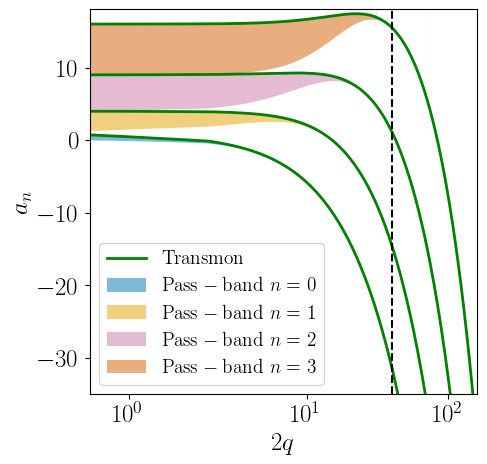

In [11]:
with open('Map_transmon_numpoints_3000.npy', 'rb') as f:
    qtestlist = np.load(f)
    tran0 = np.load(f)
    tran1 = np.load(f)
    tran2 = np.load(f)
    tran3 = np.load(f)


colors = [
    "#0072B2",  # blue
    "#E69F00",  # orange
    "#CC79A7",  # purple/pink
    "#D55E00"   # reddish orange
]
    
a0t = 4*(0+0.5)*np.sqrt(qtestlist)-2*qtestlist
a1t = 4*(1+0.5)*np.sqrt(qtestlist)-2*qtestlist
a2t = 4*(2+0.5)*np.sqrt(qtestlist)-2*qtestlist
a3t = 4*(3+0.5)*np.sqrt(qtestlist)-2*qtestlist


qtest = 20
fonty = 18
fig1 = plt.figure(1, figsize=(5, 5))
plt.rc('text', usetex=True)

plt.plot(np.NaN, np.NaN, 'g-',linewidth=2.,label=r'$\mathrm{Transmon}$')

#plt.plot(2*qq, A0e0, 'k.',markersize=1.)
#plt.plot(2*qq, A0o1, 'k.',markersize=1.)
plt.plot(2*qtestlist, tran0, 'g-',linewidth=2.)
plt.fill_between(2*qq,A0e0, A0o1, facecolor=colors[0],alpha=0.5,label=r'$\mathrm{Pass-band}$ $n=0$')
#plt.plot(2*qq, A0e1, 'k.',markersize=1.)
#plt.plot(2*qq, A0o2, 'k.',markersize=1.)
plt.plot(2*qtestlist, tran1, 'g-',linewidth=2.)
plt.fill_between(2*qq,A0e1, A0o2, facecolor=colors[1],alpha=0.5,label=r'$\mathrm{Pass-band}$ $n=1$')
#plt.plot(2*qq, A0e2, 'k.',markersize=1.)
#plt.plot(2*qq, A0o3, 'k.',markersize=1.)
plt.plot(2*qtestlist, tran2, 'g-',linewidth=2.)
plt.fill_between(2*qq,A0e2, A0o3, facecolor=colors[2],alpha=0.5,label=r'$\mathrm{Pass-band}$ $n=2$')
#plt.plot(2*qq, A0e3, 'k.',markersize=1.)
#plt.plot(2*qq, A0o4, 'k.',markersize=1.)
plt.plot(2*qtestlist, tran3, 'g-',linewidth=2.)
plt.fill_between(2*qq,A0e3, A0o4, facecolor=colors[3],alpha=0.5,label=r'$\mathrm{Pass-band}$ $n=3$')
#plt.plot(2*qq,-0.25*np.ones(qq.size),'r-',markersize=2.,alpha=0.6,label=r'$-0.25-n(n+1)/2$')
#plt.plot(2*qq,-1.25*np.ones(qq.size),'r-',markersize=2.,alpha=0.6)
#plt.plot(2*qq,-3.25*np.ones(qq.size),'r-',markersize=2.,alpha=0.6)
#plt.plot(2*qq,-6.25*np.ones(qq.size),'r-',markersize=2.,alpha=0.6)

plt.axvline(x=2*qtest, color='k', linestyle='--', alpha=1)

plt.xlabel('$2q$',fontsize=fonty)
plt.ylabel(r'$a_n$',fontsize=fonty) 
plt.xticks(size=fonty)
plt.yticks(size=fonty)
plt.xlim(0.5, 1.6e2)   # set the ylim to ymin, ymax
plt.ylim(-35., 18)   # set the ylim to ymin, ymax
plt.xscale('symlog')   
plt.legend(fontsize=fonty-4, loc='best')
fig1 = plt.gcf()
plt.show()

fig1.savefig('Convergences_Mathieu.png', format='png', dpi=1000,bbox_inches='tight')


### → Figure 3 — Transmon eigenfunctions

Plots the first few transmon eigenstates $\psi_n(\varphi)$ at a representative
value $q = E_J/(8E_C) = 20$, illustrating their harmonic-oscillator-like shape.


[-31.31339741 -14.49111706   1.16052624  15.49304153  28.46304799]
[-31.313390070336514, -14.491301425174816, 1.1542828852467468, 15.395810912805139, 27.59457815461195] [-31.313386166912924, -14.491063255980725, 1.1607056791652275, 15.493977576989293, 28.468221325102682]


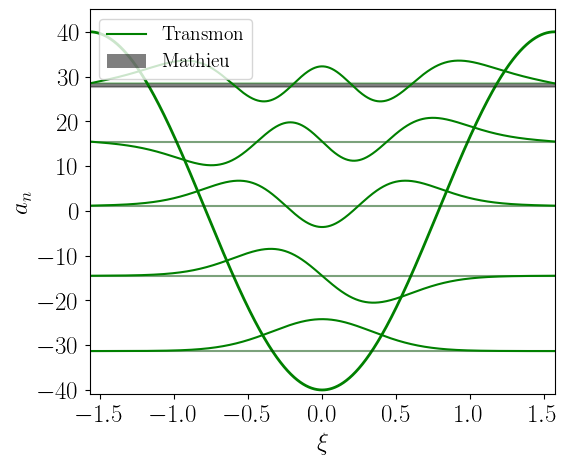

In [12]:
# Parameters for the transmon
qtest = 20
E_C = 1.0  # Charging energy
E_J = 2*qtest*E_C  # Josephson energy
num_points = 2000  # Number of grid points for φ
phi_max = np.pi  # Range for φ

# Discretize the φ range
phi = np.linspace(-phi_max, phi_max, num_points)
dphi = phi[1] - phi[0]

# Potential term: V(phi) = -E_J * cos(phi)
V = -E_J * np.cos(phi)

# Kinetic term: T = -4 * E_C * d^2/dphi^2
kinetic = -4 * E_C / dphi**2
diagonal_kinetic = np.full(num_points, -2 * kinetic)
off_diagonal_kinetic = np.full(num_points - 1, kinetic)
T = diags([diagonal_kinetic, off_diagonal_kinetic, off_diagonal_kinetic], [0, -1, 1])

# Full Hamiltonian: H = T + V
H = T + diags([V], [0])

# Solve for eigenvalues and eigenvectors
eigenvalues, eigenvectors = eigh(H.toarray())
eigenvalues = eigenvalues[:5]  # Only take the first 10 eigenvalues
eigenvectors = eigenvectors[:, :5]
print(eigenvalues)


# Calculate characteristic values (eigenvalues) for the first few Mathieu functions
n_values = range(5)  # Compute for n = 0, 1, 2, 3
eig_even = [E_C * mathieu_a(n, qtest) for n in n_values]
eig_odd = [E_C * mathieu_b(n+1, qtest) for n in n_values]
print(eig_even,eig_odd)

amp = 140
# Plot the potential and eigenfunctions
fonty = 18
fig3 = plt.figure(figsize=(6, 5))
plt.rc('text', usetex=True)

plt.plot(phi/2, -E_J * np.cos(phi),'g-',linewidth=2)
#plt.plot(phi/2, -2*qtest+4*qtest*(phi/2)**2,'r-',linewidth=2,alpha=0.2)
for i in range(5):
    aHQOcorrec = 2*(i+0.5)*np.sqrt(4*qtest)-2*qtest-(i*(i+1)/2+0.25)
    #aHQOcorrec = 2*(i+0.5)*np.sqrt(4*qtest)-2*qtest
    #plt.plot([-np.pi,np.pi], [aHQOcorrec,aHQOcorrec], 'r-',alpha=0.2)
    #plt.plot([-np.pi,np.pi], [eigenvalues[i],eigenvalues[i]], 'g:')
    plt.plot(np.array([-phi_max,phi_max]),np.array([eig_even[i],eig_even[i]]),'k-',alpha=0.3) 
    plt.plot(np.array([-phi_max,phi_max]),np.array([eig_odd[i],eig_odd[i]]),'g-',alpha=0.3)
    plt.fill_betweenx(np.array([eig_even[i],eig_odd[i]]),np.array([-phi_max,-phi_max]), np.array([phi_max,phi_max]), facecolor='k',alpha=0.5)
    plt.plot(phi/2, eigenvectors[:, i]*amp + eigenvalues[i],'g-')
    
#plt.plot([np.NaN,np.NaN], [np.NaN,np.NaN], 'r-',label=r'$\mathrm{QHO}$ $\mathrm{modified}$',alpha=0.4)
plt.plot([np.NaN,np.NaN], [np.NaN,np.NaN], 'g-',label=r'$\mathrm{Transmon}$')
plt.fill_betweenx(np.array([100,200]),np.array([-phi_max,-phi_max]), np.array([phi_max,phi_max]), 
                  facecolor='k',alpha=0.5,label=r'$\mathrm{Mathieu}$')
   

plt.xticks(size=fonty)
plt.yticks(size=fonty)
plt.xlim(-phi_max/2, phi_max/2)
plt.ylim(-2*qtest-1,2*qtest+5)
#plt.ylim(-2.5,-2)
#plt.ylim(7.5,8)
plt.xlabel(r'$\xi$', fontsize=fonty)
plt.ylabel('$a_n$', fontsize=fonty)
plt.legend(fontsize=fonty-4, loc='upper left')
plt.show()

fig3.savefig('Transmon_schrodinger_approx.png', format='png', dpi=1000,bbox_inches='tight')



#fig4 = plt.figure(figsize=(10, 6))
#plt.plot(phi, eigenvectors[:, 0]*30, label=f"Eigenstate {0}")

### → Figure 3 — Equivalence with Floquet/Bloch analysis

Loads `Map_rho_H12_negative.npy` and overlays the Floquet stability chart
with the Transmon eigenvalue locus, confirming that the two problems share
the same spectrum in the narrow-pass-band regime.


/var/folders/xc/bmsk3vw13cg973pbrrv1dh6c0000gn/T/ipykernel_65251/1540144603.py:14: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  sola = fsolve(equation_a, guess, args=(nn, s0, s1), xtol=xtol, maxfev=maxfev,factor=factor)[0]  # Solve with arguments
/var/folders/xc/bmsk3vw13cg973pbrrv1dh6c0000gn/T/ipykernel_65251/1540144603.py:15: RuntimeWarning: xtol=0.000000 is too small, no further improvement in the approximate
 solution is possible.
  solb = fsolve(equation_b, guess, args=(nn+1, s0, s1), xtol=xtol, maxfev=maxfev,factor=factor)[0]  # Solve with arguments
/var/folders/xc/bmsk3vw13cg973pbrrv1dh6c0000gn/T/ipykernel_65251/1540144603.py:14: RuntimeWarning: xtol=0.000000 is too small, no further improvement in the approximate
 solution is possible.
  sola = fsolve(equation_a, guess, args=(nn, s0, s1), xtol=xtol, maxfev=maxfev,factor=factor)[0]  # Solve with arguments
/var/folders/xc/bmsk3vw13cg973pbrrv1dh6c0000gn

[  1.64607477  18.20265375  50.98080847 100.14607039 165.69946966
 247.64112587 345.97107399 460.68932732 591.79589181 739.29077047] [  1.91484147  18.20341283  50.98080996 100.14607039 165.69946966
 247.64112587 345.97107399 460.68932732 591.79589181 739.29077047]


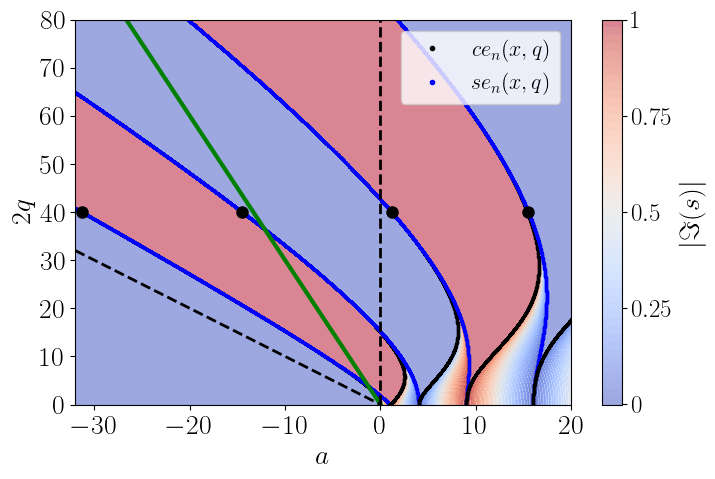

In [13]:
pent = 3
eps0 = 8.854e-12
mu0 = 1.25663706127e-6
s0 = -eps0*mu0
s1=-pent*s0


with open('Map_rho_H12_negative.npy', 'rb') as f:
    aanum = np.load(f)
    qqnum = np.load(f)
    matrho1 = np.load(f)
    matrho2 = np.load(f)
    mats1 = np.load(f)
    mats2 = np.load(f)    

matrho = np.maximum(np.abs(matrho1), np.abs(matrho2))
realsmax = np.maximum(np.real(mats1), np.real(mats2))
#print(realsmax.shape)

mat_row = np.size(aanum)
mat_col = np.size(qqnum)    
    
aanum.shape=(1,mat_row)
qqnum.shape=(1,mat_col)

Mq = np.dot(np.transpose(aanum),np.ones((1,mat_col)))
Mp = np.dot(np.ones((mat_row,1)),qqnum)


imax = 10
listqa = np.ones(imax)
listqb = np.ones(imax)

for ii in range(imax):
    #print(ii)
    [solutiona,solutionb] = solve_mathieu(ii, s0, s1, [2100])
    #[solutiona,solutionb] = solve_mathieu(ii, s0a, s1a, [(s1a/2)*(2*ii+1)**2*test**2*lamba**2/np.pi**2])
    solutiona = solutiona[0]
    solutionb = solutionb[0]
    #[solutiona,solutionb] = solve_with_min(ii, s0a, s1a, (ii*10,1000*ii))
    #[solutiona,solutionb] = solve_with_newton(ii, s0a, s1a, (s1a/2)*(2*ii+1)**2*test**2*lamba**2/np.pi**2)
    #solutiona = solutiona[0]
    #solutionb = solutionb[0]    
    #print(solutiona,solutionb)
    listqa[ii] = solutiona
    listqb[ii] = solutionb
    
print(listqa,listqb)

# Define the range of q values
qq = np.linspace(-50, 50, 10000)
aa = np.linspace(-100, 100, 10000)


# Calculate Mathieu function characteristic values
A0e = [mathieu_a(n, qq) for n in range(5)]  # Even modes
A0o = [mathieu_b(n, qq) for n in range(1, 6)]  # Odd modes

# Set font size for plots
fonty = 20
levelou = np.linspace(0.01,(np.amax(np.asarray(realsmax))),100)
leveli = np.linspace(-0.0001,1+0.0001,50)

fig1 = plt.figure(1, figsize=(8, 5))
plt.rc('text', usetex=True)

# Plot characteristic curves with swapped axes
colors = ['k', 'b']
for i, (a, b) in enumerate(zip(A0e, A0o)):
    plt.plot(a, 2*qq, f'{colors[0]}.', markersize=2.5)
    plt.plot(b, 2*qq, f'{colors[1]}.', markersize=2.5)
    
plt.plot(np.NaN, np.NaN, f'{colors[0]}.', markersize=6., label=r'$ce_n(x,q)$')
plt.plot(np.NaN, np.NaN, f'{colors[1]}.', markersize=6., label=r'$se_n(x,q)$')


#sc = plt.scatter(Mq, Mp, c=realsmax, cmap=plt.cm.coolwarm, s=marker_size, alpha=alphadata)
#sc = plt.contourf(Mq,2*Mp,realsmax, cmap=plt.cm.coolwarm,levels=levelou,alpha=0.6)
#sc = plt.contourf(Mq,2*Mp,realsmax, 100,cmap=plt.cm.coolwarm,alpha=0.6)
#sc = plt.contourf(Mq,2*Mp,np.abs(np.imag(mats2))*(Mq+Mp)/2,100, cmap=plt.cm.coolwarm,alpha=0.6)
#sc = plt.contourf(Mq,2*Mp,np.abs(np.imag(mats2)), cmap=plt.cm.coolwarm,levels=leveli,alpha=0.6)
sc = plt.contourf(Mq,2*Mp,np.abs(np.imag(mats2)), cmap=plt.cm.coolwarm,levels=leveli,alpha=0.5)


# Colorbar
cbar = plt.colorbar(sc, format='%.1f')

# Set colorbar label and font size
cbar.set_label(r'$|\Im(s)|$', fontsize=fonty)  # Adjust font size as needed

# Define the tick locations and corresponding labels
tick_locations = [0, 0.25, 0.5, 0.75, 1]
tick_labels = [r'$0$', r'$0.25$', r'$0.5$', r'$0.75$', r'$1$']

# Set the ticks and labels
cbar.set_ticks(tick_locations)
cbar.set_ticklabels(tick_labels)

# Set tick parameters for font size
cbar.ax.tick_params(labelsize=fonty-2)  # Adjust font size as needed



# Fill stability regions with swapped axes
#plt.fill_betweenx(2*qq, -100 * np.ones(qq.size), A0e[0], facecolor='b', alpha=0.5)
#for i in range(1, len(A0e)):
#    plt.fill_betweenx(2*qq, A0o[i-1], A0e[i], facecolor='g' if i % 2 else 'b', alpha=0.5)


plt.plot(aa, 2*aa*s1/(2*s0), 'g-',linewidth=3) 
#plt.plot(aa, 2*aa*0.6/2, 'k-',linewidth=2)
plt.plot([0.,0.],[0.,100.], 'k--',linewidth=2) 
plt.plot([-32.,0.],[32.,0.], 'k--',linewidth=2) 
#plt.plot([0.,30.],[0.,30.], 'k--',linewidth=2)
#plt.plot(aa, -aa*s1/(2*s0), 'k-') 

plt.plot(eigenvalues,np.ones(eigenvalues.size)*qtest*2, 'k.',markersize=16)
    
# Customize axes
plt.xticks(size=fonty)
plt.yticks(size=fonty)
plt.xlabel(r'$a$', fontsize=fonty)  # x-axis: a
plt.ylabel(r'$2q$', fontsize=fonty)  # y-axis: q
plt.xlim(-32, 20.)
plt.ylim(0.,80.)
#plt.grid()
plt.xscale('linear')
plt.yscale('linear')

# Add legend
plt.legend(fontsize=fonty-4, loc='upper right')

# Show and save the plot
fig1 = plt.gcf()
plt.show()

#fig1.savefig('Mathieu_stability_chart_aq_negative.png', format='png', dpi=1000, bbox_inches='tight')

### → Figure 3 — Bloch wave profiles (modes $n = 0, 1, 2, 3$)

Time-domain integration of the Mathieu ODE for the four lowest pass-band frequencies.
Each cell produces one panel showing the wave envelope analogous to the
corresponding Transmon eigenstate.


5.2703592611591704e+16
(0.5999996695688832+0.800000249389434j) (0.5999996695688832-0.8000002493894343j)
1.0000000012529628 1.0000000012529628
[ 1.93582229e-17+0.43225903j -1.93582229e-17-0.43225903j]


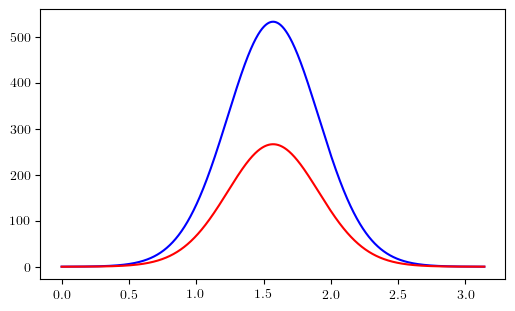

1.9999989587893279
5.270359129762057e+16
(-0.20000049855665414+0.9797957939100064j) (-0.20000049855665428-0.9797957939100065j)
0.9999999985933249 0.999999998593325
[-1.4732058e-16+1.03493342j  1.4732058e-16-1.03493342j]


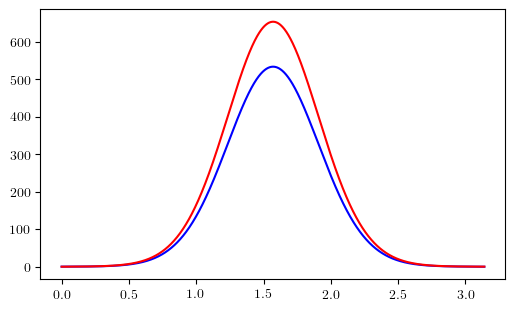

0.8164961576146168


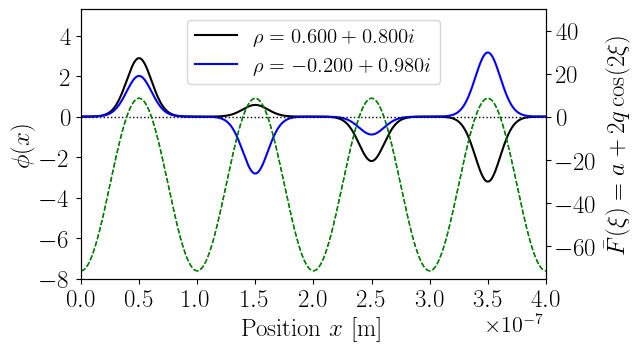

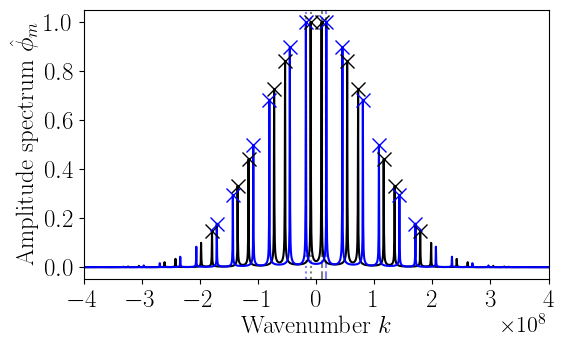

In [21]:
lamb = 100e-9
kmax = 2e8
modevis = 0
nT = int(100)
nTvisu = 4
y0 = np.array([0.2,0.])

nprimary = 2000
nFloq = nprimary+1
listcell = np.linspace(0, np.pi, nFloq)
dt = listcell[1]-listcell[0]

listt = np.linspace(0.,np.pi*nT-dt,nT*nprimary)

y_1 = [1.0, 0.0]
y_2 = [0.0, 1.0]

###########################################################################
atest0 = eig_even[modevis]+0.2*(eig_odd[modevis]-eig_even[modevis])
omega0 = np.sqrt(atest0*(np.pi**2)/(s0*lamb**2))
print(omega0)


sol1 = solve_ivp(equation_lin, [0, np.pi], y_1, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atest0, qtest))
sol2 = solve_ivp(equation_lin, [0, np.pi], y_2, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atest0, qtest))
# Assembly of the monodromy matrix Phi
mat_phi = np.array([ [ sol1.y[0,-1], sol2.y[0,-1]  ] , [ sol1.y[1,-1], sol2.y[1,-1] ] ],dtype=complex)
eigenValfloq, eigenVecfloq = scipy.linalg.eig(mat_phi)
rho1 = eigenValfloq[0]
rho2 = eigenValfloq[1]
eigVector1 = eigenVecfloq[:,0]
eigVector2 = eigenVecfloq[:,1]
ff1         = cm.log(rho1)/np.pi
ff2         = cm.log(rho2)/np.pi

print(rho1,rho2)
print(np.abs(rho1),np.abs(rho2))    


#The Floquet form computation
mode_floquet1 = solve_ivp(sol_comp_mode_floquet, [0, np.pi], eigVector1, method='RK45',rtol=1e-14,atol=1e-18,
                t_eval=listcell,args=(atest0, qtest, ff1)) 
mode_floquet2 = solve_ivp(sol_comp_mode_floquet, [0, np.pi], eigVector2, method='RK45',rtol=1e-14,atol=1e-18,
                t_eval=listcell,args=(atest0, qtest, ff2))


# Reconstruction of a response with Floquet forms superposition
cci = np.dot(np.linalg.inv(eigenVecfloq),y0)
print(cci)

fig5, ax1 = plt.subplots(1, figsize=(6, 3.5))
plt.rc('text', usetex=True)
plt.plot(listcell[0:-1:1],np.real(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))),'b-')
plt.plot(listcell[0:-1:1],np.imag(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))),'r-')
plt.show()
print(np.max(np.abs(np.real(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1])))))/np.max(np.abs(np.imag(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))))))

MAtFloq = np.zeros((nT,nprimary),dtype=complex)
OptiFloq = np.zeros((nT,nprimary),dtype=complex)
MAtFloqp = np.zeros((nT,nprimary),dtype=complex)

listrhon0A = np.linspace(0,1,nT)
for ii in range(nT):
    MAtFloq[ii,:] = 2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]+ii*np.pi))
    MAtFloqp[ii,:] = 2*cci[0]*mode_floquet1.y[1,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]+ii*np.pi))
    #OptiFloq[ii,:] = 2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))*rho1**ii #General formula in the case of any initial conditions 
    OptiFloq[ii,:] = (1+0.5j)*eigenvectors[:, modevis]*rho1**ii #We can try some complex constant 
    
qlist0 = MAtFloq.reshape((int(nT*nprimary),))
qplist0 = MAtFloqp.reshape((int(nT*nprimary),)) 
qopti0 = OptiFloq.reshape((int(nT*nprimary),))

solist = solve_ivp(equation_lin, [0, np.pi*nT-dt], y0, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=listt,args=(atest0, qtest))
q0 = solist.y[0,:]
qp0 = solist.y[1,:]


# Compute the FFT
L = np.max(listt*lamb/np.pi)
wave = np.real(q0)
# Length of the wave
N_wave = len(wave)
# Choose FFT length (must match the length of the wave for FFT)
N = N_wave  # Use the actual wave length for FFT
fft_wave = np.fft.fft(wave)
fft_wave = fft_wave / N  # Normalize the amplitude
# Compute the wavenumbers
k = 2 * np.pi * np.fft.fftfreq(N, d=L / N)  # Wavenumbers
k = np.fft.fftshift(k)                      # Shift wavenumbers
# Shift the FFT for symmetry
fft_wave_shifted = np.fft.fftshift(fft_wave)

# Find peaks
peak_wavenumbers, peak_amplitudes = find_fft_peaks(fft_wave_shifted, k, height=0.5, distance=1)
#print(peak_amplitudes)
fftadim =  np.abs(fft_wave_shifted)/np.max(peak_amplitudes)
q0adim = np.real(q0)/np.max(peak_amplitudes)
peak_waveadim0, peak_ampadim0 = find_fft_peaks(fftadim, k, height=0.1, distance=1)

#indou = np.argmax(peak_amplitudes)
#kfund = peak_wavenumbers[indou]

MAtFloq0A = MAtFloq
rho0A = rho1
coeff0A = (1+0.5j)





#y0 = np.array([0.045,0.2]) #This is for a constant of OptiFloq = (1+0.5j) 
###########################################################################
atest1 = eig_even[modevis]+0.6*(eig_odd[modevis]-eig_even[modevis])
omega1 = np.sqrt(atest1*(np.pi**2)/(s0*lamb**2))
print(omega1)


sol1 = solve_ivp(equation_lin, [0, np.pi], y_1, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atest1, qtest))
sol2 = solve_ivp(equation_lin, [0, np.pi], y_2, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atest1, qtest))
# Assembly of the monodromy matrix Phi
mat_phi = np.array([ [ sol1.y[0,-1], sol2.y[0,-1]  ] , [ sol1.y[1,-1], sol2.y[1,-1] ] ],dtype=complex)
eigenValfloq, eigenVecfloq = scipy.linalg.eig(mat_phi)
rho1 = eigenValfloq[0]
rho2 = eigenValfloq[1]
eigVector1 = eigenVecfloq[:,0]
eigVector2 = eigenVecfloq[:,1]
ff1         = cm.log(rho1)/np.pi
ff2         = cm.log(rho2)/np.pi

print(rho1,rho2)
print(np.abs(rho1),np.abs(rho2))    


#The Floquet form computation
mode_floquet1 = solve_ivp(sol_comp_mode_floquet, [0, np.pi], eigVector1, method='RK45',rtol=1e-14,atol=1e-18,
                t_eval=listcell,args=(atest1, qtest, ff1)) 
mode_floquet2 = solve_ivp(sol_comp_mode_floquet, [0, np.pi], eigVector2, method='RK45',rtol=1e-14,atol=1e-18,
                t_eval=listcell,args=(atest1, qtest, ff2))


# Reconstruction of a response with Floquet forms superposition
cci = np.dot(np.linalg.inv(eigenVecfloq),y0)
print(cci)

fig6, ax1 = plt.subplots(1, figsize=(6, 3.5))
plt.rc('text', usetex=True)
plt.plot(listcell[0:-1:1],np.real(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))),'b-')
plt.plot(listcell[0:-1:1],np.imag(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))),'r-')
plt.show()
print(np.max(np.abs(np.real(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1])))))/np.max(np.abs(np.imag(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))))))

MAtFloq = np.zeros((nT,nprimary),dtype=complex)
OptiFloq = np.zeros((nT,nprimary),dtype=complex)
MAtFloqp = np.zeros((nT,nprimary),dtype=complex)

for ii in range(nT):
    MAtFloq[ii,:] = cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]+ii*np.pi))+\
    cci[1]*mode_floquet2.y[0,0:-1:1]*np.exp(ff2*(listcell[0:-1:1]+ii*np.pi))
    MAtFloqp[ii,:] = cci[0]*mode_floquet1.y[1,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]+ii*np.pi))+\
    cci[1]*mode_floquet2.y[1,0:-1:1]*np.exp(ff2*(listcell[0:-1:1]+ii*np.pi))
    #OptiFloq[ii,:] = 2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))*rho1**ii #General formula in the case of any initial conditions  
    OptiFloq[ii,:] = eigenvectors[:, modevis]*np.real((1+(1/0.8165)*1j)*rho1**ii)

    
qlist1 = MAtFloq.reshape((int(nT*nprimary),))
qplist1 = MAtFloqp.reshape((int(nT*nprimary),))
qopti1 = OptiFloq.reshape((int(nT*nprimary),))

solist = solve_ivp(equation_lin, [0, np.pi*nT-dt], y0, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=listt,args=(atest1, qtest))
q1 = solist.y[0,:]
qp1 = solist.y[1,:]


# Compute the FFT
L = np.max(listt*lamb/np.pi)
wave1 = np.real(q1)
# Length of the wave
N_wave = len(wave1)
# Choose FFT length (must match the length of the wave for FFT)
N = N_wave  # Use the actual wave length for FFT
fft_wave1 = np.fft.fft(wave1)
fft_wave1 = fft_wave1 / N  # Normalize the amplitude
# Compute the wavenumbers
k1 = 2 * np.pi * np.fft.fftfreq(N, d=L / N)  # Wavenumbers
k1 = np.fft.fftshift(k1)                      # Shift wavenumbers
# Shift the FFT for symmetry
fft_wave_shifted1 = np.fft.fftshift(fft_wave1)

# Find peaks
peak_wavenumbers1, peak_amplitudes1 = find_fft_peaks(fft_wave_shifted1, k, height=0.5, distance=1)
#print(peak_amplitudes)
fftadim1 =  np.abs(fft_wave_shifted1)/np.max(peak_amplitudes1)
q0adim1 = np.real(q1)/np.max(peak_amplitudes1)
peak_waveadim1, peak_ampadim1 = find_fft_peaks(fftadim1, k1, height=0.1, distance=1)


MAtFloq0B = MAtFloq
rho0B = rho1
coeff0B = (1+(1/0.8165)*1j)







ampi = 0.4
fonty = 18
fig5, ax1 = plt.subplots(1, figsize=(6, 3.5))
plt.rc('text', usetex=True)

ax2 = ax1.twinx()

# Add vertical dashed lines
#for i in range(0, nTvisu):
    #x_pos = i * lamb + 0.5*lamb
    #ax1.axvline(x=x_pos, color='r', linestyle='--', alpha=0.7)
    
# Add vertical dashed lines
#for i in range(0, 4):
    #x_pos = 0.805*lamb + i * (2*np.pi/np.abs(kfund))
    #plt.axvline(x=x_pos, color='b', linestyle='--', alpha=0.7)    

#ax1.plot(listt*lamb/np.pi,q0*0.01,'k-',linewidth=1.5,label=r'ODE solver')
#ax1.plot(listt*lamb/np.pi,qlist0*0.01,'b-',linewidth=1.5,label=r'Floquet form')
#ax1.plot(listt*lamb/np.pi,qopti0*105,'r-',linewidth=1.5,label=r'OPti')
#ax1.plot(listt*lamb/np.pi,q1*0.01,'g-',linewidth=1.5,label=r'ODE solver')
#ax1.plot(listt*lamb/np.pi,qlist1*0.01,'r-',linewidth=1.5,label=r'Floquet form')
#ax1.plot(listt*lamb/np.pi,qopti1*105,'r-',linewidth=1.5,label=r'Opti')

ax1.plot(listt*lamb/np.pi,q0adim*ampi,'k-',linewidth=1.5,label=r'$\rho=0.600+0.800i$')
ax1.plot(listt*lamb/np.pi,q0adim1*ampi,'b-',linewidth=1.5,label=r'$\rho=-0.200+0.980i$')

yplot = atest0+2*qtest*np.cos(2*(listt-np.pi/2))
yplot1 = atest1+2*qtest*np.cos(2*(listt-np.pi/2))
ax2.plot(listt*lamb/np.pi, yplot, 'g--',linewidth=1.)
ax2.plot(listt*lamb/np.pi, yplot1, 'g--',linewidth=1.)
ax1.plot(np.array([listt[0],listt[-1]]), np.array([0.,0.]), 'k:',linewidth=1.)

# Set font size for the offset text
ax1.xaxis.get_offset_text().set_fontsize(fonty-2)
#ax.yaxis.get_offset_text().set_fontsize(fonty-2)

#ax1.set_yticks([-8, -6, -4, -2, 0, 2])
#ax1.set_yticklabels(['140', '150', '160', '170', '180','190'], fontsize=fonty)  # Set the desired labels

ax1.set_ylim(-8, 5.3)
ax2.set_ylim(-75, 50)
plt.xlim(0, nTvisu*lamb)
ax1.set_xlabel(r'$\mathrm{Position}$ $x$ $\mathrm{[m]}$',fontsize=fonty)
ax1.set_ylabel(r'$\phi(x)$',fontsize=fonty)
ax2.set_ylabel(r'$\bar{F}(\xi)=a+2q\cos(2\xi)$',fontsize=fonty)
plt.setp(ax1.get_xticklabels(), fontsize=fonty)
plt.setp(ax1.get_yticklabels(), fontsize=fonty)
plt.setp(ax2.get_xticklabels(), fontsize=fonty)
plt.setp(ax2.get_yticklabels(), fontsize=fonty)
ax1.legend(fontsize=fonty-3,loc='upper center')
fig5 = plt.gcf()
plt.show()

fig5.savefig('Mathieu_mode0_transmon.png', format='png', dpi=1000,bbox_inches='tight')






fonty = 18
fig5 = plt.figure(5, figsize=(6, 3.5))
plt.rc('text', usetex=True)

# Add vertical dashed lines
for i in range(-0,1):
    x_pos1 = peak_waveadim0[int(len(peak_waveadim0)/2)] + i * (2*np.pi / lamb)
    x_pos2 = peak_waveadim0[int(len(peak_waveadim0)/2-1)] + i * (2*np.pi / lamb)
    plt.axvline(x=x_pos1, color='k', linestyle='--', alpha=0.5)
    plt.axvline(x=x_pos2, color='k', linestyle=':', alpha=0.5)
    x_pos3 = peak_waveadim1[int(len(peak_waveadim1)/2)] + i * (2*np.pi / lamb)
    x_pos4 = peak_waveadim1[int(len(peak_waveadim1)/2-1)] + i * (2*np.pi / lamb)
    plt.axvline(x=x_pos3, color='b', linestyle='--', alpha=0.5)
    plt.axvline(x=x_pos4, color='b', linestyle=':', alpha=0.5)    

#plt.plot(listt,np.real(qplist0),'g-',linewidth=1.5)
#plt.axvline(x=np.abs(kfund), color='b', linestyle='--', alpha=0.7)
#plt.axvline(x=-np.abs(kfund), color='b', linestyle='--', alpha=0.7)
plt.plot(k, fftadim,'k')
plt.plot(k1, fftadim1,'b')
plt.plot(peak_waveadim0, peak_ampadim0,'xk',markersize=10)
plt.plot(peak_waveadim1, peak_ampadim1,'xb',markersize=10)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
#ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.xlabel(r'$\mathrm{Wavenumber}$ $k$',fontsize=fonty)
#plt.ylabel(r'Amplitude spectrum $\hat{\phi}_m = \sum_{n=0}^{N-1} \phi_n e^{-i \frac{2\pi}{N} m n}$',fontsize=fonty)
plt.ylabel(r'$\mathrm{Amplitude}$ $\mathrm{spectrum}$ $\hat{\phi}_m$',fontsize=fonty)
plt.xlim(-2*kmax, 2*kmax)   # set the ylim to ymin, ymax
plt.xticks(size=fonty)
plt.yticks(size=fonty)
#legend = plt.legend(fontsize=fonty,loc='best')
fig5 = plt.gcf()
plt.show()

#fig5.savefig('Mathieu_mode0_FFT.png', format='png', dpi=1000,bbox_inches='tight')



3.5853219762708864e+16
(-0.5999828105462162+0.8000128917683094j) (-0.5999828105462159-0.8000128917683093j)
0.9999999999732146 0.9999999999732144
[-3.15510172e-17-0.37986917j  3.15510172e-17+0.37986917j]


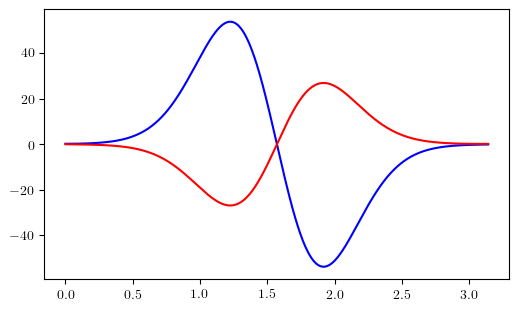

1.9999426592799199
3.585310191029093e+16
(0.2000257841381008+0.9797906335899754j) (0.20002578413810074-0.9797906335899752j)
0.9999999999953537 0.9999999999953535
[ 5.89071881e-17-0.90321761j -5.89071881e-17+0.90321761j]


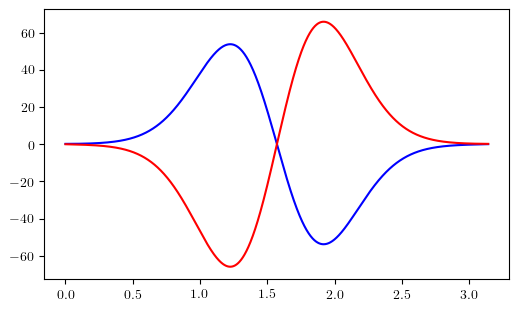

0.8164751447141524


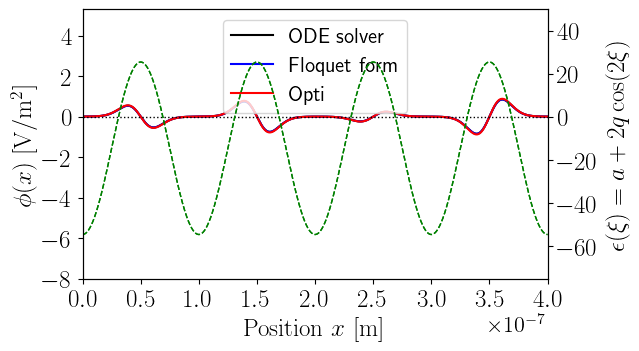

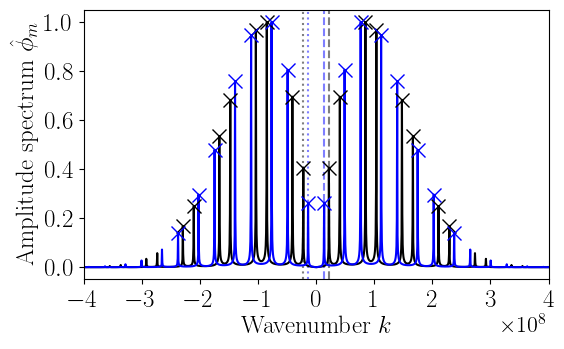

In [22]:
lamb = 100e-9
kmax = 2e8
modevis = 1
nT = int(100)
nTvisu = 4
y0 = np.array([0.2,0.])

nprimary = 2000
nFloq = nprimary+1
listcell = np.linspace(0, np.pi, nFloq)
dt = listcell[1]-listcell[0]

listt = np.linspace(0.,np.pi*nT-dt,nT*nprimary)

y_1 = [1.0, 0.0]
y_2 = [0.0, 1.0]

###########################################################################
atest0 = eig_even[modevis]+0.2*(eig_odd[modevis]-eig_even[modevis])
omega0 = np.sqrt(atest0*(np.pi**2)/(s0*lamb**2))
print(omega0)


sol1 = solve_ivp(equation_lin, [0, np.pi], y_1, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atest0, qtest))
sol2 = solve_ivp(equation_lin, [0, np.pi], y_2, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atest0, qtest))
# Assembly of the monodromy matrix Phi
mat_phi = np.array([ [ sol1.y[0,-1], sol2.y[0,-1]  ] , [ sol1.y[1,-1], sol2.y[1,-1] ] ],dtype=complex)
eigenValfloq, eigenVecfloq = scipy.linalg.eig(mat_phi)
rho1 = eigenValfloq[0]
rho2 = eigenValfloq[1]
eigVector1 = eigenVecfloq[:,0]
eigVector2 = eigenVecfloq[:,1]
ff1         = cm.log(rho1)/np.pi
ff2         = cm.log(rho2)/np.pi

print(rho1,rho2)
print(np.abs(rho1),np.abs(rho2))    


#The Floquet form computation
mode_floquet1 = solve_ivp(sol_comp_mode_floquet, [0, np.pi], eigVector1, method='RK45',rtol=1e-14,atol=1e-18,
                t_eval=listcell,args=(atest0, qtest, ff1)) 
mode_floquet2 = solve_ivp(sol_comp_mode_floquet, [0, np.pi], eigVector2, method='RK45',rtol=1e-14,atol=1e-18,
                t_eval=listcell,args=(atest0, qtest, ff2))


# Reconstruction of a response with Floquet forms superposition
cci = np.dot(np.linalg.inv(eigenVecfloq),y0)
print(cci)

fig5, ax1 = plt.subplots(1, figsize=(6, 3.5))
plt.rc('text', usetex=True)
plt.plot(listcell[0:-1:1],np.real(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))),'b-')
plt.plot(listcell[0:-1:1],np.imag(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))),'r-')
plt.show()
print(np.max(np.abs(np.real(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1])))))/np.max(np.abs(np.imag(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))))))

MAtFloq = np.zeros((nT,nprimary),dtype=complex)
OptiFloq = np.zeros((nT,nprimary),dtype=complex)
MAtFloqp = np.zeros((nT,nprimary),dtype=complex)

listrhon0A = np.linspace(0,1,nT)
for ii in range(nT):
    MAtFloq[ii,:] = 2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]+ii*np.pi))
    MAtFloqp[ii,:] = 2*cci[0]*mode_floquet1.y[1,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]+ii*np.pi))
    #OptiFloq[ii,:] = 2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))*rho1**ii #General formula in the case of any initial conditions 
    OptiFloq[ii,:] = (1-0.5j)*eigenvectors[:, modevis]*rho1**ii #We can try some complex constant 
    
qlist0 = MAtFloq.reshape((int(nT*nprimary),))
qplist0 = MAtFloqp.reshape((int(nT*nprimary),)) 
qopti0 = OptiFloq.reshape((int(nT*nprimary),))

solist = solve_ivp(equation_lin, [0, np.pi*nT-dt], y0, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=listt,args=(atest0, qtest))
q0 = solist.y[0,:]
qp0 = solist.y[1,:]


# Compute the FFT
L = np.max(listt*lamb/np.pi)
wave = np.real(q0)
# Length of the wave
N_wave = len(wave)
# Choose FFT length (must match the length of the wave for FFT)
N = N_wave  # Use the actual wave length for FFT
fft_wave = np.fft.fft(wave)
fft_wave = fft_wave / N  # Normalize the amplitude
# Compute the wavenumbers
k = 2 * np.pi * np.fft.fftfreq(N, d=L / N)  # Wavenumbers
k = np.fft.fftshift(k)                      # Shift wavenumbers
# Shift the FFT for symmetry
fft_wave_shifted = np.fft.fftshift(fft_wave)

# Find peaks
peak_wavenumbers, peak_amplitudes = find_fft_peaks(fft_wave_shifted, k, height=0.5, distance=1)
#print(peak_amplitudes)
fftadim =  np.abs(fft_wave_shifted)/np.max(peak_amplitudes)
q0adim = np.real(q0)/np.max(peak_amplitudes)
peak_waveadim0, peak_ampadim0 = find_fft_peaks(fftadim, k, height=0.1, distance=1)

#indou = np.argmax(peak_amplitudes)
#kfund = peak_wavenumbers[indou]

MAtFloq1A = MAtFloq
rho1A = rho1
coeff1A = (1-0.5j)





#y0 = np.array([0.045,0.2]) #This is for a constant of OptiFloq = (1+0.5j) 
###########################################################################
atest1 = eig_even[modevis]+0.6*(eig_odd[modevis]-eig_even[modevis])
omega1 = np.sqrt(atest1*(np.pi**2)/(s0*lamb**2))
print(omega1)


sol1 = solve_ivp(equation_lin, [0, np.pi], y_1, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atest1, qtest))
sol2 = solve_ivp(equation_lin, [0, np.pi], y_2, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atest1, qtest))
# Assembly of the monodromy matrix Phi
mat_phi = np.array([ [ sol1.y[0,-1], sol2.y[0,-1]  ] , [ sol1.y[1,-1], sol2.y[1,-1] ] ],dtype=complex)
eigenValfloq, eigenVecfloq = scipy.linalg.eig(mat_phi)
rho1 = eigenValfloq[0]
rho2 = eigenValfloq[1]
eigVector1 = eigenVecfloq[:,0]
eigVector2 = eigenVecfloq[:,1]
ff1         = cm.log(rho1)/np.pi
ff2         = cm.log(rho2)/np.pi

print(rho1,rho2)
print(np.abs(rho1),np.abs(rho2))    


#The Floquet form computation
mode_floquet1 = solve_ivp(sol_comp_mode_floquet, [0, np.pi], eigVector1, method='RK45',rtol=1e-14,atol=1e-18,
                t_eval=listcell,args=(atest1, qtest, ff1)) 
mode_floquet2 = solve_ivp(sol_comp_mode_floquet, [0, np.pi], eigVector2, method='RK45',rtol=1e-14,atol=1e-18,
                t_eval=listcell,args=(atest1, qtest, ff2))


# Reconstruction of a response with Floquet forms superposition
cci = np.dot(np.linalg.inv(eigenVecfloq),y0)
print(cci)

fig6, ax1 = plt.subplots(1, figsize=(6, 3.5))
plt.rc('text', usetex=True)
plt.plot(listcell[0:-1:1],np.real(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))),'b-')
plt.plot(listcell[0:-1:1],np.imag(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))),'r-')
plt.show()
print(np.max(np.abs(np.real(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1])))))/np.max(np.abs(np.imag(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))))))

MAtFloq = np.zeros((nT,nprimary),dtype=complex)
OptiFloq = np.zeros((nT,nprimary),dtype=complex)
MAtFloqp = np.zeros((nT,nprimary),dtype=complex)

for ii in range(nT):
    MAtFloq[ii,:] = cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]+ii*np.pi))+\
    cci[1]*mode_floquet2.y[0,0:-1:1]*np.exp(ff2*(listcell[0:-1:1]+ii*np.pi))
    MAtFloqp[ii,:] = cci[0]*mode_floquet1.y[1,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]+ii*np.pi))+\
    cci[1]*mode_floquet2.y[1,0:-1:1]*np.exp(ff2*(listcell[0:-1:1]+ii*np.pi))
    #OptiFloq[ii,:] = 2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))*rho1**ii #General formula in the case of any initial conditions  
    OptiFloq[ii,:] = eigenvectors[:, modevis]*np.real((1-(1/0.8165)*1j)*rho1**ii)

    
qlist1 = MAtFloq.reshape((int(nT*nprimary),))
qplist1 = MAtFloqp.reshape((int(nT*nprimary),))
qopti1 = OptiFloq.reshape((int(nT*nprimary),))

solist = solve_ivp(equation_lin, [0, np.pi*nT-dt], y0, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=listt,args=(atest1, qtest))
q1 = solist.y[0,:]
qp1 = solist.y[1,:]


# Compute the FFT
L = np.max(listt*lamb/np.pi)
wave1 = np.real(q1)
# Length of the wave
N_wave = len(wave1)
# Choose FFT length (must match the length of the wave for FFT)
N = N_wave  # Use the actual wave length for FFT
fft_wave1 = np.fft.fft(wave1)
fft_wave1 = fft_wave1 / N  # Normalize the amplitude
# Compute the wavenumbers
k1 = 2 * np.pi * np.fft.fftfreq(N, d=L / N)  # Wavenumbers
k1 = np.fft.fftshift(k1)                      # Shift wavenumbers
# Shift the FFT for symmetry
fft_wave_shifted1 = np.fft.fftshift(fft_wave1)

# Find peaks
peak_wavenumbers1, peak_amplitudes1 = find_fft_peaks(fft_wave_shifted1, k, height=0.5, distance=1)
#print(peak_amplitudes)
fftadim1 =  np.abs(fft_wave_shifted1)/np.max(peak_amplitudes1)
q0adim1 = np.real(q1)/np.max(peak_amplitudes1)
peak_waveadim1, peak_ampadim1 = find_fft_peaks(fftadim1, k1, height=0.1, distance=1)


MAtFloq1B = MAtFloq
rho1B = rho1
coeff1B = (1-(1/0.8165)*1j)







ampi = 0.4
fonty = 18
fig5, ax1 = plt.subplots(1, figsize=(6, 3.5))
plt.rc('text', usetex=True)

ax2 = ax1.twinx()

# Add vertical dashed lines
#for i in range(0, nTvisu):
    #x_pos = i * lamb + 0.5*lamb
    #ax1.axvline(x=x_pos, color='r', linestyle='--', alpha=0.7)
    
# Add vertical dashed lines
#for i in range(0, 4):
    #x_pos = 0.805*lamb + i * (2*np.pi/np.abs(kfund))
    #plt.axvline(x=x_pos, color='b', linestyle='--', alpha=0.7)    

#ax1.plot(listt*lamb/np.pi,q0*0.01,'k-',linewidth=1.5,label=r'ODE solver')
#ax1.plot(listt*lamb/np.pi,qlist0*0.01,'b-',linewidth=1.5,label=r'Floquet form')
#ax1.plot(listt*lamb/np.pi,qopti0*13,'r-',linewidth=1.5,label=r'OPti')
ax1.plot(listt*lamb/np.pi,q1*0.01,'k-',linewidth=1.5,label=r'ODE solver')
ax1.plot(listt*lamb/np.pi,qlist1*0.01,'b-',linewidth=1.5,label=r'Floquet form')
ax1.plot(listt*lamb/np.pi,qopti1*13,'r-',linewidth=1.5,label=r'Opti')

#ax1.plot(listt*lamb/np.pi,q0adim*ampi,'k-',linewidth=1.5,label=r'$\rho=0.600+0.800i$')
#ax1.plot(listt*lamb/np.pi,q0adim1*ampi,'b-',linewidth=1.5,label=r'$\rho=-0.200+0.980i$')

yplot = atest0+2*qtest*np.cos(2*(listt-np.pi/2))
yplot1 = atest1+2*qtest*np.cos(2*(listt-np.pi/2))
ax2.plot(listt*lamb/np.pi, yplot, 'g--',linewidth=1.)
ax2.plot(listt*lamb/np.pi, yplot1, 'g--',linewidth=1.)
ax1.plot(np.array([listt[0],listt[-1]]), np.array([0.,0.]), 'k:',linewidth=1.)

# Set font size for the offset text
ax1.xaxis.get_offset_text().set_fontsize(fonty-2)
#ax.yaxis.get_offset_text().set_fontsize(fonty-2)

#ax1.set_yticks([-8, -6, -4, -2, 0, 2])
#ax1.set_yticklabels(['140', '150', '160', '170', '180','190'], fontsize=fonty)  # Set the desired labels

ax1.set_ylim(-8, 5.3)
ax2.set_ylim(-75, 50)
plt.xlim(0, nTvisu*lamb)
ax1.set_xlabel(r'$\mathrm{Position}$ $x$ $\mathrm{[m]}$',fontsize=fonty)
ax1.set_ylabel(r'$\phi(x)$ $\mathrm{[V/m^2]}$',fontsize=fonty)
ax2.set_ylabel(r'$\epsilon(\xi)=a+2q\cos(2\xi)$',fontsize=fonty)
plt.setp(ax1.get_xticklabels(), fontsize=fonty)
plt.setp(ax1.get_yticklabels(), fontsize=fonty)
plt.setp(ax2.get_xticklabels(), fontsize=fonty)
plt.setp(ax2.get_yticklabels(), fontsize=fonty)
ax1.legend(fontsize=fonty-3,loc='upper center')
fig5 = plt.gcf()
plt.show()

fig5.savefig('Mathieu_mode1_transmon.png', format='png', dpi=1000,bbox_inches='tight')






fonty = 18
fig5 = plt.figure(5, figsize=(6, 3.5))
plt.rc('text', usetex=True)

# Add vertical dashed lines
for i in range(-0,1):
    x_pos1 = peak_waveadim0[int(len(peak_waveadim0)/2)] + i * (2*np.pi / lamb)
    x_pos2 = peak_waveadim0[int(len(peak_waveadim0)/2-1)] + i * (2*np.pi / lamb)
    plt.axvline(x=x_pos1, color='k', linestyle='--', alpha=0.5)
    plt.axvline(x=x_pos2, color='k', linestyle=':', alpha=0.5)
    x_pos3 = peak_waveadim1[int(len(peak_waveadim1)/2)] + i * (2*np.pi / lamb)
    x_pos4 = peak_waveadim1[int(len(peak_waveadim1)/2-1)] + i * (2*np.pi / lamb)
    plt.axvline(x=x_pos3, color='b', linestyle='--', alpha=0.5)
    plt.axvline(x=x_pos4, color='b', linestyle=':', alpha=0.5)    

#plt.plot(listt,np.real(qplist0),'g-',linewidth=1.5)
#plt.axvline(x=np.abs(kfund), color='b', linestyle='--', alpha=0.7)
#plt.axvline(x=-np.abs(kfund), color='b', linestyle='--', alpha=0.7)
plt.plot(k, fftadim,'k')
plt.plot(k1, fftadim1,'b')
plt.plot(peak_waveadim0, peak_ampadim0,'xk',markersize=10)
plt.plot(peak_waveadim1, peak_ampadim1,'xb',markersize=10)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
#ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.xlabel(r'$\mathrm{Wavenumber}$ $k$',fontsize=fonty)
#plt.ylabel(r'Amplitude spectrum $\hat{\phi}_m = \sum_{n=0}^{N-1} \phi_n e^{-i \frac{2\pi}{N} m n}$',fontsize=fonty)
plt.ylabel(r'$\mathrm{Amplitude}$ $\mathrm{spectrum}$ $\hat{\phi}_m$',fontsize=fonty)
plt.xlim(-2*kmax, 2*kmax)   # set the ylim to ymin, ymax
plt.xticks(size=fonty)
plt.yticks(size=fonty)
#legend = plt.legend(fontsize=fonty,loc='best')
fig5 = plt.gcf()
plt.show()

#fig5.savefig('Mathieu_mode0_FFT.png', format='png', dpi=1000,bbox_inches='tight')



/var/folders/xc/bmsk3vw13cg973pbrrv1dh6c0000gn/T/ipykernel_65251/1571477229.py:20: RuntimeWarning: invalid value encountered in sqrt
  omega0 = np.sqrt(atest0*(np.pi**2)/(s0*lamb**2))


nan
(0.5995839562632581+0.8003118638323683j) (0.5995839562632583-0.8003118638323685j)
0.9999999999995699 0.9999999999995702
[ 3.1432561e-17+0.32296921j -3.1432561e-17-0.32296921j]


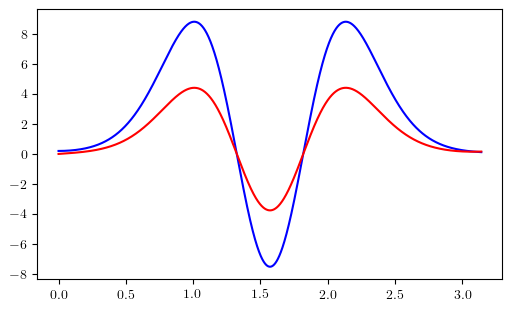

1.998575612371302


/var/folders/xc/bmsk3vw13cg973pbrrv1dh6c0000gn/T/ipykernel_65251/1571477229.py:116: RuntimeWarning: invalid value encountered in sqrt
  omega1 = np.sqrt(atest1*(np.pi**2)/(s0*lamb**2))


nan
(-0.2006239565758307+0.9796683255288801j) (-0.20062395657583063-0.9796683255288801j)
0.9999999999983502 0.9999999999983502
[ 7.65790233e-17+0.75882453j -7.65790233e-17-0.75882453j]


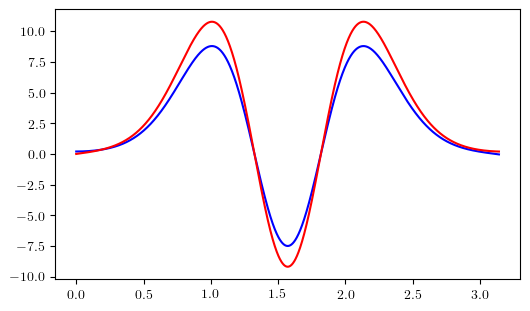

0.8159831213749662


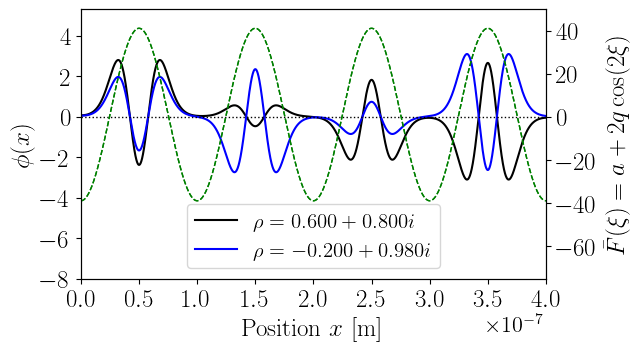

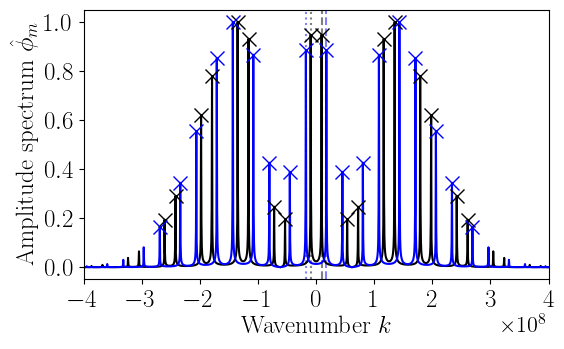

In [23]:
lamb = 100e-9
kmax = 2e8
modevis = 2
nT = int(100)
nTvisu = 4
y0 = np.array([0.2,0.])

nprimary = 2000
nFloq = nprimary+1
listcell = np.linspace(0, np.pi, nFloq)
dt = listcell[1]-listcell[0]

listt = np.linspace(0.,np.pi*nT-dt,nT*nprimary)

y_1 = [1.0, 0.0]
y_2 = [0.0, 1.0]

###########################################################################
atest0 = eig_even[modevis]+0.2*(eig_odd[modevis]-eig_even[modevis])
omega0 = np.sqrt(atest0*(np.pi**2)/(s0*lamb**2))
print(omega0)


sol1 = solve_ivp(equation_lin, [0, np.pi], y_1, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atest0, qtest))
sol2 = solve_ivp(equation_lin, [0, np.pi], y_2, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atest0, qtest))
# Assembly of the monodromy matrix Phi
mat_phi = np.array([ [ sol1.y[0,-1], sol2.y[0,-1]  ] , [ sol1.y[1,-1], sol2.y[1,-1] ] ],dtype=complex)
eigenValfloq, eigenVecfloq = scipy.linalg.eig(mat_phi)
rho1 = eigenValfloq[0]
rho2 = eigenValfloq[1]
eigVector1 = eigenVecfloq[:,0]
eigVector2 = eigenVecfloq[:,1]
ff1         = cm.log(rho1)/np.pi
ff2         = cm.log(rho2)/np.pi

print(rho1,rho2)
print(np.abs(rho1),np.abs(rho2))    


#The Floquet form computation
mode_floquet1 = solve_ivp(sol_comp_mode_floquet, [0, np.pi], eigVector1, method='RK45',rtol=1e-14,atol=1e-18,
                t_eval=listcell,args=(atest0, qtest, ff1)) 
mode_floquet2 = solve_ivp(sol_comp_mode_floquet, [0, np.pi], eigVector2, method='RK45',rtol=1e-14,atol=1e-18,
                t_eval=listcell,args=(atest0, qtest, ff2))


# Reconstruction of a response with Floquet forms superposition
cci = np.dot(np.linalg.inv(eigenVecfloq),y0)
print(cci)

fig5, ax1 = plt.subplots(1, figsize=(6, 3.5))
plt.rc('text', usetex=True)
plt.plot(listcell[0:-1:1],np.real(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))),'b-')
plt.plot(listcell[0:-1:1],np.imag(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))),'r-')
plt.show()
print(np.max(np.abs(np.real(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1])))))/np.max(np.abs(np.imag(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))))))

MAtFloq = np.zeros((nT,nprimary),dtype=complex)
OptiFloq = np.zeros((nT,nprimary),dtype=complex)
MAtFloqp = np.zeros((nT,nprimary),dtype=complex)

for ii in range(nT):
    MAtFloq[ii,:] = 2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]+ii*np.pi))
    MAtFloqp[ii,:] = 2*cci[0]*mode_floquet1.y[1,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]+ii*np.pi))
    #OptiFloq[ii,:] = 2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))*rho1**ii #General formula in the case of any initial conditions 
    OptiFloq[ii,:] = (1+0.5j)*eigenvectors[:, modevis]*rho1**ii #We can try some complex constant 
    
qlist0 = MAtFloq.reshape((int(nT*nprimary),))
qplist0 = MAtFloqp.reshape((int(nT*nprimary),)) 
qopti0 = OptiFloq.reshape((int(nT*nprimary),))

solist = solve_ivp(equation_lin, [0, np.pi*nT-dt], y0, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=listt,args=(atest0, qtest))
q0 = solist.y[0,:]
qp0 = solist.y[1,:]


# Compute the FFT
L = np.max(listt*lamb/np.pi)
wave = np.real(q0)
# Length of the wave
N_wave = len(wave)
# Choose FFT length (must match the length of the wave for FFT)
N = N_wave  # Use the actual wave length for FFT
fft_wave = np.fft.fft(wave)
fft_wave = fft_wave / N  # Normalize the amplitude
# Compute the wavenumbers
k = 2 * np.pi * np.fft.fftfreq(N, d=L / N)  # Wavenumbers
k = np.fft.fftshift(k)                      # Shift wavenumbers
# Shift the FFT for symmetry
fft_wave_shifted = np.fft.fftshift(fft_wave)

# Find peaks
peak_wavenumbers, peak_amplitudes = find_fft_peaks(fft_wave_shifted, k, height=0.5, distance=1)
#print(peak_amplitudes)
fftadim =  np.abs(fft_wave_shifted)/np.max(peak_amplitudes)
q0adim = np.real(q0)/np.max(peak_amplitudes)
peak_waveadim0, peak_ampadim0 = find_fft_peaks(fftadim, k, height=0.1, distance=1)

#indou = np.argmax(peak_amplitudes)
#kfund = peak_wavenumbers[indou]

MAtFloq2A = MAtFloq
rho2A = rho1
coeff2A = (1+0.5j)





#y0 = np.array([0.045,0.2]) #This is for a constant of OptiFloq = (1+0.5j) 
###########################################################################
atest1 = eig_even[modevis]+0.6*(eig_odd[modevis]-eig_even[modevis])
omega1 = np.sqrt(atest1*(np.pi**2)/(s0*lamb**2))
print(omega1)


sol1 = solve_ivp(equation_lin, [0, np.pi], y_1, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atest1, qtest))
sol2 = solve_ivp(equation_lin, [0, np.pi], y_2, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atest1, qtest))
# Assembly of the monodromy matrix Phi
mat_phi = np.array([ [ sol1.y[0,-1], sol2.y[0,-1]  ] , [ sol1.y[1,-1], sol2.y[1,-1] ] ],dtype=complex)
eigenValfloq, eigenVecfloq = scipy.linalg.eig(mat_phi)
rho1 = eigenValfloq[0]
rho2 = eigenValfloq[1]
eigVector1 = eigenVecfloq[:,0]
eigVector2 = eigenVecfloq[:,1]
ff1         = cm.log(rho1)/np.pi
ff2         = cm.log(rho2)/np.pi

print(rho1,rho2)
print(np.abs(rho1),np.abs(rho2))    


#The Floquet form computation
mode_floquet1 = solve_ivp(sol_comp_mode_floquet, [0, np.pi], eigVector1, method='RK45',rtol=1e-14,atol=1e-18,
                t_eval=listcell,args=(atest1, qtest, ff1)) 
mode_floquet2 = solve_ivp(sol_comp_mode_floquet, [0, np.pi], eigVector2, method='RK45',rtol=1e-14,atol=1e-18,
                t_eval=listcell,args=(atest1, qtest, ff2))


# Reconstruction of a response with Floquet forms superposition
cci = np.dot(np.linalg.inv(eigenVecfloq),y0)
print(cci)

fig6, ax1 = plt.subplots(1, figsize=(6, 3.5))
plt.rc('text', usetex=True)
plt.plot(listcell[0:-1:1],np.real(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))),'b-')
plt.plot(listcell[0:-1:1],np.imag(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))),'r-')
plt.show()
print(np.max(np.abs(np.real(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1])))))/np.max(np.abs(np.imag(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))))))

MAtFloq = np.zeros((nT,nprimary),dtype=complex)
OptiFloq = np.zeros((nT,nprimary),dtype=complex)
MAtFloqp = np.zeros((nT,nprimary),dtype=complex)

for ii in range(nT):
    MAtFloq[ii,:] = cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]+ii*np.pi))+\
    cci[1]*mode_floquet2.y[0,0:-1:1]*np.exp(ff2*(listcell[0:-1:1]+ii*np.pi))
    MAtFloqp[ii,:] = cci[0]*mode_floquet1.y[1,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]+ii*np.pi))+\
    cci[1]*mode_floquet2.y[1,0:-1:1]*np.exp(ff2*(listcell[0:-1:1]+ii*np.pi))
    #OptiFloq[ii,:] = 2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))*rho1**ii #General formula in the case of any initial conditions  
    OptiFloq[ii,:] = eigenvectors[:, modevis]*np.real((1+(1/0.816)*1j)*rho1**ii)

    
qlist1 = MAtFloq.reshape((int(nT*nprimary),))
qplist1 = MAtFloqp.reshape((int(nT*nprimary),))
qopti1 = OptiFloq.reshape((int(nT*nprimary),))

solist = solve_ivp(equation_lin, [0, np.pi*nT-dt], y0, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=listt,args=(atest1, qtest))
q1 = solist.y[0,:]
qp1 = solist.y[1,:]


# Compute the FFT
L = np.max(listt*lamb/np.pi)
wave1 = np.real(q1)
# Length of the wave
N_wave = len(wave1)
# Choose FFT length (must match the length of the wave for FFT)
N = N_wave  # Use the actual wave length for FFT
fft_wave1 = np.fft.fft(wave1)
fft_wave1 = fft_wave1 / N  # Normalize the amplitude
# Compute the wavenumbers
k1 = 2 * np.pi * np.fft.fftfreq(N, d=L / N)  # Wavenumbers
k1 = np.fft.fftshift(k1)                      # Shift wavenumbers
# Shift the FFT for symmetry
fft_wave_shifted1 = np.fft.fftshift(fft_wave1)

# Find peaks
peak_wavenumbers1, peak_amplitudes1 = find_fft_peaks(fft_wave_shifted1, k, height=0.5, distance=1)
#print(peak_amplitudes)
fftadim1 =  np.abs(fft_wave_shifted1)/np.max(peak_amplitudes1)
q0adim1 = np.real(q1)/np.max(peak_amplitudes1)
peak_waveadim1, peak_ampadim1 = find_fft_peaks(fftadim1, k1, height=0.1, distance=1)


MAtFloq2B = MAtFloq
rho2B = rho1
coeff2B = (1+(1/0.816)*1j)







ampi = 0.4
fonty = 18
fig5, ax1 = plt.subplots(1, figsize=(6, 3.5))
plt.rc('text', usetex=True)

ax2 = ax1.twinx()

# Add vertical dashed lines
#for i in range(0, nTvisu):
    #x_pos = i * lamb + 0.5*lamb
    #ax1.axvline(x=x_pos, color='r', linestyle='--', alpha=0.7)
    
# Add vertical dashed lines
#for i in range(0, 4):
    #x_pos = 0.805*lamb + i * (2*np.pi/np.abs(kfund))
    #plt.axvline(x=x_pos, color='b', linestyle='--', alpha=0.7)    

#ax1.plot(listt*lamb/np.pi,q0*0.1,'k-',linewidth=1.5,label=r'ODE solver')
#ax1.plot(listt*lamb/np.pi,qlist0*0.1,'b-',linewidth=1.5,label=r'Floquet form')
#ax1.plot(listt*lamb/np.pi,qopti0*21,'r-',linewidth=1.5,label=r'OPti')
#ax1.plot(listt*lamb/np.pi,q1*0.1,'k-',linewidth=1.5,label=r'ODE solver')
#ax1.plot(listt*lamb/np.pi,qlist1*0.1,'b-',linewidth=1.5,label=r'Floquet form')
#ax1.plot(listt*lamb/np.pi,qopti1*21,'r-',linewidth=1.5,label=r'Opti')

ax1.plot(listt*lamb/np.pi,q0adim*ampi,'k-',linewidth=1.5,label=r'$\rho=0.600+0.800i$')
ax1.plot(listt*lamb/np.pi,q0adim1*ampi,'b-',linewidth=1.5,label=r'$\rho=-0.200+0.980i$')

yplot = atest0+2*qtest*np.cos(2*(listt-np.pi/2))
yplot1 = atest1+2*qtest*np.cos(2*(listt-np.pi/2))
ax2.plot(listt*lamb/np.pi, yplot, 'g--',linewidth=1.)
ax2.plot(listt*lamb/np.pi, yplot1, 'g--',linewidth=1.)
ax1.plot(np.array([listt[0],listt[-1]]), np.array([0.,0.]), 'k:',linewidth=1.)

# Set font size for the offset text
ax1.xaxis.get_offset_text().set_fontsize(fonty-2)
#ax.yaxis.get_offset_text().set_fontsize(fonty-2)

#ax1.set_yticks([-8, -6, -4, -2, 0, 2])
#ax1.set_yticklabels(['140', '150', '160', '170', '180','190'], fontsize=fonty)  # Set the desired labels

ax1.set_ylim(-8, 5.3)
ax2.set_ylim(-75, 50)
plt.xlim(0, nTvisu*lamb)
ax1.set_xlabel(r'$\mathrm{Position}$ $x$ $\mathrm{[m]}$',fontsize=fonty)
ax1.set_ylabel(r'$\phi(x)$',fontsize=fonty)
ax2.set_ylabel(r'$\bar{F}(\xi)=a+2q\cos(2\xi)$',fontsize=fonty)
plt.setp(ax1.get_xticklabels(), fontsize=fonty)
plt.setp(ax1.get_yticklabels(), fontsize=fonty)
plt.setp(ax2.get_xticklabels(), fontsize=fonty)
plt.setp(ax2.get_yticklabels(), fontsize=fonty)
ax1.legend(fontsize=fonty-3,loc='lower center')
fig5 = plt.gcf()
plt.show()

fig5.savefig('Mathieu_mode2_transmon.png', format='png', dpi=1000,bbox_inches='tight')






fonty = 18
fig5 = plt.figure(5, figsize=(6, 3.5))
plt.rc('text', usetex=True)

# Add vertical dashed lines
for i in range(-0,1):
    x_pos1 = peak_waveadim0[int(len(peak_waveadim0)/2)] + i * (2*np.pi / lamb)
    x_pos2 = peak_waveadim0[int(len(peak_waveadim0)/2-1)] + i * (2*np.pi / lamb)
    plt.axvline(x=x_pos1, color='k', linestyle='--', alpha=0.5)
    plt.axvline(x=x_pos2, color='k', linestyle=':', alpha=0.5)
    x_pos3 = peak_waveadim1[int(len(peak_waveadim1)/2)] + i * (2*np.pi / lamb)
    x_pos4 = peak_waveadim1[int(len(peak_waveadim1)/2-1)] + i * (2*np.pi / lamb)
    plt.axvline(x=x_pos3, color='b', linestyle='--', alpha=0.5)
    plt.axvline(x=x_pos4, color='b', linestyle=':', alpha=0.5)    

#plt.plot(listt,np.real(qplist0),'g-',linewidth=1.5)
#plt.axvline(x=np.abs(kfund), color='b', linestyle='--', alpha=0.7)
#plt.axvline(x=-np.abs(kfund), color='b', linestyle='--', alpha=0.7)
plt.plot(k, fftadim,'k')
plt.plot(k1, fftadim1,'b')
plt.plot(peak_waveadim0, peak_ampadim0,'xk',markersize=10)
plt.plot(peak_waveadim1, peak_ampadim1,'xb',markersize=10)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
#ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.xlabel(r'$\mathrm{Wavenumber}$ $k$',fontsize=fonty)
#plt.ylabel(r'Amplitude spectrum $\hat{\phi}_m = \sum_{n=0}^{N-1} \phi_n e^{-i \frac{2\pi}{N} m n}$',fontsize=fonty)
plt.ylabel(r'$\mathrm{Amplitude}$ $\mathrm{spectrum}$ $\hat{\phi}_m$',fontsize=fonty)
plt.xlim(-2*kmax, 2*kmax)   # set the ylim to ymin, ymax
plt.xticks(size=fonty)
plt.yticks(size=fonty)
#legend = plt.legend(fontsize=fonty,loc='best')
fig5 = plt.gcf()
plt.show()

#fig5.savefig('Mathieu_mode0_FFT.png', format='png', dpi=1000,bbox_inches='tight')



/var/folders/xc/bmsk3vw13cg973pbrrv1dh6c0000gn/T/ipykernel_65251/1134788387.py:20: RuntimeWarning: invalid value encountered in sqrt
  omega0 = np.sqrt(atest0*(np.pi**2)/(s0*lamb**2))


nan
(-0.5941137448774287+0.8043810403956184j) (-0.5941137448774285-0.8043810403956184j)
1.00000000000011 1.00000000000011
[-4.66709918e-17-0.26004757j  4.66709918e-17+0.26004757j]


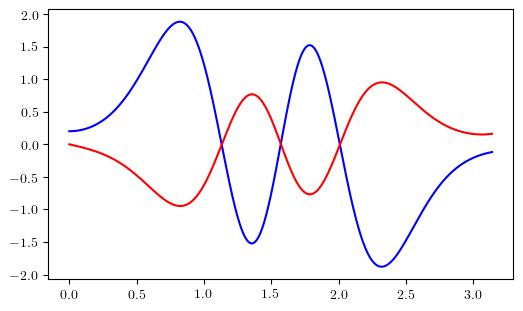

1.979323313680796


/var/folders/xc/bmsk3vw13cg973pbrrv1dh6c0000gn/T/ipykernel_65251/1134788387.py:116: RuntimeWarning: invalid value encountered in sqrt
  omega1 = np.sqrt(atest1*(np.pi**2)/(s0*lamb**2))


nan
(0.20881279532104657+0.9779556311562191j) (0.20881279532104657-0.977955631156219j)
0.999999999999974 0.9999999999999739
[-6.27638151e-17-0.59590835j  6.27638151e-17+0.59590835j]


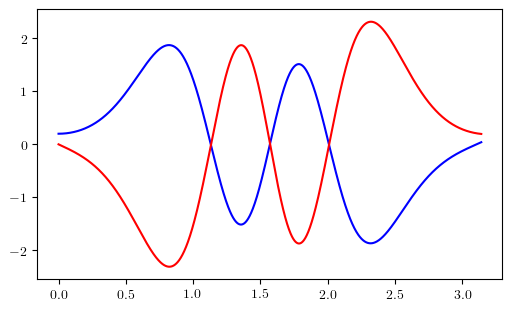

0.8093805252277434


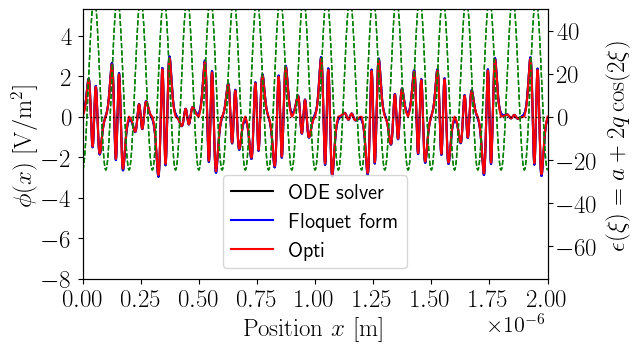

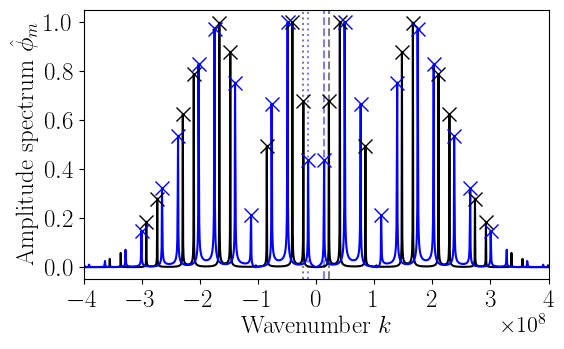

In [24]:
lamb = 100e-9
kmax = 2e8
modevis = 3
nT = int(100)
nTvisu = 20
y0 = np.array([0.2,0.])

nprimary = 2000
nFloq = nprimary+1
listcell = np.linspace(0, np.pi, nFloq)
dt = listcell[1]-listcell[0]

listt = np.linspace(0.,np.pi*nT-dt,nT*nprimary)

y_1 = [1.0, 0.0]
y_2 = [0.0, 1.0]

###########################################################################
atest0 = eig_even[modevis]+0.2*(eig_odd[modevis]-eig_even[modevis])
omega0 = np.sqrt(atest0*(np.pi**2)/(s0*lamb**2))
print(omega0)


sol1 = solve_ivp(equation_lin, [0, np.pi], y_1, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atest0, qtest))
sol2 = solve_ivp(equation_lin, [0, np.pi], y_2, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atest0, qtest))
# Assembly of the monodromy matrix Phi
mat_phi = np.array([ [ sol1.y[0,-1], sol2.y[0,-1]  ] , [ sol1.y[1,-1], sol2.y[1,-1] ] ],dtype=complex)
eigenValfloq, eigenVecfloq = scipy.linalg.eig(mat_phi)
rho1 = eigenValfloq[0]
rho2 = eigenValfloq[1]
eigVector1 = eigenVecfloq[:,0]
eigVector2 = eigenVecfloq[:,1]
ff1         = cm.log(rho1)/np.pi
ff2         = cm.log(rho2)/np.pi

print(rho1,rho2)
print(np.abs(rho1),np.abs(rho2))    


#The Floquet form computation
mode_floquet1 = solve_ivp(sol_comp_mode_floquet, [0, np.pi], eigVector1, method='RK45',rtol=1e-14,atol=1e-18,
                t_eval=listcell,args=(atest0, qtest, ff1)) 
mode_floquet2 = solve_ivp(sol_comp_mode_floquet, [0, np.pi], eigVector2, method='RK45',rtol=1e-14,atol=1e-18,
                t_eval=listcell,args=(atest0, qtest, ff2))


# Reconstruction of a response with Floquet forms superposition
cci = np.dot(np.linalg.inv(eigenVecfloq),y0)
print(cci)

fig5, ax1 = plt.subplots(1, figsize=(6, 3.5))
plt.rc('text', usetex=True)
plt.plot(listcell[0:-1:1],np.real(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))),'b-')
plt.plot(listcell[0:-1:1],np.imag(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))),'r-')
plt.show()
print(np.max(np.abs(np.real(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1])))))/np.max(np.abs(np.imag(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))))))

MAtFloq = np.zeros((nT,nprimary),dtype=complex)
OptiFloq = np.zeros((nT,nprimary),dtype=complex)
MAtFloqp = np.zeros((nT,nprimary),dtype=complex)

for ii in range(nT):
    MAtFloq[ii,:] = 2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]+ii*np.pi))
    MAtFloqp[ii,:] = 2*cci[0]*mode_floquet1.y[1,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]+ii*np.pi))
    #OptiFloq[ii,:] = 2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))*rho1**ii #General formula in the case of any initial conditions 
    OptiFloq[ii,:] = (1-(1/1.979)*1j)*eigenvectors[:, modevis]*rho1**ii #We can try some complex constant 
    
qlist0 = MAtFloq.reshape((int(nT*nprimary),))
qplist0 = MAtFloqp.reshape((int(nT*nprimary),)) 
qopti0 = OptiFloq.reshape((int(nT*nprimary),))

solist = solve_ivp(equation_lin, [0, np.pi*nT-dt], y0, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=listt,args=(atest0, qtest))
q0 = solist.y[0,:]
qp0 = solist.y[1,:]


# Compute the FFT
L = np.max(listt*lamb/np.pi)
wave = np.real(q0)
# Length of the wave
N_wave = len(wave)
# Choose FFT length (must match the length of the wave for FFT)
N = N_wave  # Use the actual wave length for FFT
fft_wave = np.fft.fft(wave)
fft_wave = fft_wave / N  # Normalize the amplitude
# Compute the wavenumbers
k = 2 * np.pi * np.fft.fftfreq(N, d=L / N)  # Wavenumbers
k = np.fft.fftshift(k)                      # Shift wavenumbers
# Shift the FFT for symmetry
fft_wave_shifted = np.fft.fftshift(fft_wave)

# Find peaks
peak_wavenumbers, peak_amplitudes = find_fft_peaks(fft_wave_shifted, k, height=0.1, distance=1)
#print(peak_amplitudes)
fftadim =  np.abs(fft_wave_shifted)/np.max(peak_amplitudes)
q0adim = np.real(q0)/np.max(peak_amplitudes)
peak_waveadim0, peak_ampadim0 = find_fft_peaks(fftadim, k, height=0.1, distance=1)

#indou = np.argmax(peak_amplitudes)
#kfund = peak_wavenumbers[indou]

MAtFloq3A = MAtFloq
rho3A = rho1
coeff3A = (1-(1/1.979)*1j)





#y0 = np.array([0.045,0.2]) #This is for a constant of OptiFloq = (1+0.5j) 
###########################################################################
atest1 = eig_even[modevis]+0.6*(eig_odd[modevis]-eig_even[modevis])
omega1 = np.sqrt(atest1*(np.pi**2)/(s0*lamb**2))
print(omega1)


sol1 = solve_ivp(equation_lin, [0, np.pi], y_1, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atest1, qtest))
sol2 = solve_ivp(equation_lin, [0, np.pi], y_2, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atest1, qtest))
# Assembly of the monodromy matrix Phi
mat_phi = np.array([ [ sol1.y[0,-1], sol2.y[0,-1]  ] , [ sol1.y[1,-1], sol2.y[1,-1] ] ],dtype=complex)
eigenValfloq, eigenVecfloq = scipy.linalg.eig(mat_phi)
rho1 = eigenValfloq[0]
rho2 = eigenValfloq[1]
eigVector1 = eigenVecfloq[:,0]
eigVector2 = eigenVecfloq[:,1]
ff1         = cm.log(rho1)/np.pi
ff2         = cm.log(rho2)/np.pi

print(rho1,rho2)
print(np.abs(rho1),np.abs(rho2))    


#The Floquet form computation
mode_floquet1 = solve_ivp(sol_comp_mode_floquet, [0, np.pi], eigVector1, method='RK45',rtol=1e-14,atol=1e-18,
                t_eval=listcell,args=(atest1, qtest, ff1)) 
mode_floquet2 = solve_ivp(sol_comp_mode_floquet, [0, np.pi], eigVector2, method='RK45',rtol=1e-14,atol=1e-18,
                t_eval=listcell,args=(atest1, qtest, ff2))


# Reconstruction of a response with Floquet forms superposition
cci = np.dot(np.linalg.inv(eigenVecfloq),y0)
print(cci)

fig6, ax1 = plt.subplots(1, figsize=(6, 3.5))
plt.rc('text', usetex=True)
plt.plot(listcell[0:-1:1],np.real(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))),'b-')
plt.plot(listcell[0:-1:1],np.imag(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))),'r-')
plt.show()
print(np.max(np.abs(np.real(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1])))))/np.max(np.abs(np.imag(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))))))

MAtFloq = np.zeros((nT,nprimary),dtype=complex)
OptiFloq = np.zeros((nT,nprimary),dtype=complex)
MAtFloqp = np.zeros((nT,nprimary),dtype=complex)

for ii in range(nT):
    MAtFloq[ii,:] = cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]+ii*np.pi))+\
    cci[1]*mode_floquet2.y[0,0:-1:1]*np.exp(ff2*(listcell[0:-1:1]+ii*np.pi))
    MAtFloqp[ii,:] = cci[0]*mode_floquet1.y[1,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]+ii*np.pi))+\
    cci[1]*mode_floquet2.y[1,0:-1:1]*np.exp(ff2*(listcell[0:-1:1]+ii*np.pi))
    #OptiFloq[ii,:] = 2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))*rho1**ii #General formula in the case of any initial conditions  
    OptiFloq[ii,:] = eigenvectors[:, modevis]*np.real((1-(1/0.8094)*1j)*rho1**ii)

    
qlist1 = MAtFloq.reshape((int(nT*nprimary),))
qplist1 = MAtFloqp.reshape((int(nT*nprimary),))
qopti1 = OptiFloq.reshape((int(nT*nprimary),))

solist = solve_ivp(equation_lin, [0, np.pi*nT-dt], y0, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=listt,args=(atest1, qtest))
q1 = solist.y[0,:]
qp1 = solist.y[1,:]


# Compute the FFT
L = np.max(listt*lamb/np.pi)
wave1 = np.real(q1)
# Length of the wave
N_wave = len(wave1)
# Choose FFT length (must match the length of the wave for FFT)
N = N_wave  # Use the actual wave length for FFT
fft_wave1 = np.fft.fft(wave1)
fft_wave1 = fft_wave1 / N  # Normalize the amplitude
# Compute the wavenumbers
k1 = 2 * np.pi * np.fft.fftfreq(N, d=L / N)  # Wavenumbers
k1 = np.fft.fftshift(k1)                      # Shift wavenumbers
# Shift the FFT for symmetry
fft_wave_shifted1 = np.fft.fftshift(fft_wave1)

# Find peaks
peak_wavenumbers1, peak_amplitudes1 = find_fft_peaks(fft_wave_shifted1, k, height=0.1, distance=1)
#print(peak_amplitudes)
fftadim1 =  np.abs(fft_wave_shifted1)/np.max(peak_amplitudes1)
q0adim1 = np.real(q1)/np.max(peak_amplitudes1)
peak_waveadim1, peak_ampadim1 = find_fft_peaks(fftadim1, k1, height=0.1, distance=1)


MAtFloq3B = MAtFloq
rho3B = rho1
coeff3B = (1-(1/0.8094)*1j)







ampi = 0.4
fonty = 18
fig5, ax1 = plt.subplots(1, figsize=(6, 3.5))
plt.rc('text', usetex=True)

ax2 = ax1.twinx()

# Add vertical dashed lines
#for i in range(0, nTvisu):
    #x_pos = i * lamb + 0.5*lamb
    #ax1.axvline(x=x_pos, color='r', linestyle='--', alpha=0.7)
    
# Add vertical dashed lines
#for i in range(0, 4):
    #x_pos = 0.805*lamb + i * (2*np.pi/np.abs(kfund))
    #plt.axvline(x=x_pos, color='b', linestyle='--', alpha=0.7)    

#ax1.plot(listt*lamb/np.pi,q0*1,'k-',linewidth=1.5,label=r'ODE solver')
#ax1.plot(listt*lamb/np.pi,qlist0*1,'b-',linewidth=1.5,label=r'Floquet form')
#ax1.plot(listt*lamb/np.pi,-qopti0*48,'r-',linewidth=1.5,label=r'OPti')
ax1.plot(listt*lamb/np.pi,q1*1,'k-',linewidth=1.5,label=r'ODE solver')
ax1.plot(listt*lamb/np.pi,qlist1*1,'b-',linewidth=1.5,label=r'Floquet form')
ax1.plot(listt*lamb/np.pi,-qopti1*48,'r-',linewidth=1.5,label=r'Opti')

#ax1.plot(listt*lamb/np.pi,q0adim*ampi,'k-',linewidth=1.5,label=r'$\rho=0.600+0.800i$')
#ax1.plot(listt*lamb/np.pi,q0adim1*ampi,'b-',linewidth=1.5,label=r'$\rho=-0.200+0.980i$')

yplot = atest0+2*qtest*np.cos(2*(listt-np.pi/2))
yplot1 = atest1+2*qtest*np.cos(2*(listt-np.pi/2))
ax2.plot(listt*lamb/np.pi, yplot, 'g--',linewidth=1.)
ax2.plot(listt*lamb/np.pi, yplot1, 'g--',linewidth=1.)
ax1.plot(np.array([listt[0],listt[-1]]), np.array([0.,0.]), 'k:',linewidth=1.)

# Set font size for the offset text
ax1.xaxis.get_offset_text().set_fontsize(fonty-2)
#ax.yaxis.get_offset_text().set_fontsize(fonty-2)

#ax1.set_yticks([-8, -6, -4, -2, 0, 2])
#ax1.set_yticklabels(['140', '150', '160', '170', '180','190'], fontsize=fonty)  # Set the desired labels

ax1.set_ylim(-8, 5.3)
ax2.set_ylim(-75, 50)
plt.xlim(0, nTvisu*lamb)
ax1.set_xlabel(r'$\mathrm{Position}$ $x$ $\mathrm{[m]}$',fontsize=fonty)
ax1.set_ylabel(r'$\phi(x)$ $\mathrm{[V/m^2]}$',fontsize=fonty)
ax2.set_ylabel(r'$\epsilon(\xi)=a+2q\cos(2\xi)$',fontsize=fonty)
plt.setp(ax1.get_xticklabels(), fontsize=fonty)
plt.setp(ax1.get_yticklabels(), fontsize=fonty)
plt.setp(ax2.get_xticklabels(), fontsize=fonty)
plt.setp(ax2.get_yticklabels(), fontsize=fonty)
ax1.legend(fontsize=fonty-3,loc='lower center')
fig5 = plt.gcf()
plt.show()

#fig5.savefig('Mathieu_mode3_transmon.png', format='png', dpi=1000,bbox_inches='tight')






fonty = 18
fig5 = plt.figure(5, figsize=(6, 3.5))
plt.rc('text', usetex=True)

# Add vertical dashed lines
for i in range(-0,1):
    x_pos1 = peak_waveadim0[int(len(peak_waveadim0)/2)] + i * (2*np.pi / lamb)
    x_pos2 = peak_waveadim0[int(len(peak_waveadim0)/2-1)] + i * (2*np.pi / lamb)
    plt.axvline(x=x_pos1, color='k', linestyle='--', alpha=0.5)
    plt.axvline(x=x_pos2, color='k', linestyle=':', alpha=0.5)
    x_pos3 = peak_waveadim1[int(len(peak_waveadim1)/2)] + i * (2*np.pi / lamb)
    x_pos4 = peak_waveadim1[int(len(peak_waveadim1)/2-1)] + i * (2*np.pi / lamb)
    plt.axvline(x=x_pos3, color='b', linestyle='--', alpha=0.5)
    plt.axvline(x=x_pos4, color='b', linestyle=':', alpha=0.5)    

#plt.plot(listt,np.real(qplist0),'g-',linewidth=1.5)
#plt.axvline(x=np.abs(kfund), color='b', linestyle='--', alpha=0.7)
#plt.axvline(x=-np.abs(kfund), color='b', linestyle='--', alpha=0.7)
plt.plot(k, fftadim,'k')
plt.plot(k1, fftadim1,'b')
plt.plot(peak_waveadim0, peak_ampadim0,'xk',markersize=10)
plt.plot(peak_waveadim1, peak_ampadim1,'xb',markersize=10)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
#ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.xlabel(r'$\mathrm{Wavenumber}$ $k$',fontsize=fonty)
#plt.ylabel(r'Amplitude spectrum $\hat{\phi}_m = \sum_{n=0}^{N-1} \phi_n e^{-i \frac{2\pi}{N} m n}$',fontsize=fonty)
plt.ylabel(r'$\mathrm{Amplitude}$ $\mathrm{spectrum}$ $\hat{\phi}_m$',fontsize=fonty)
plt.xlim(-2*kmax, 2*kmax)   # set the ylim to ymin, ymax
plt.xticks(size=fonty)
plt.yticks(size=fonty)
#legend = plt.legend(fontsize=fonty,loc='best')
fig5 = plt.gcf()
plt.show()

#fig5.savefig('Mathieu_mode0_FFT.png', format='png', dpi=1000,bbox_inches='tight')



### → Figure 3 — Transmon wavefunction comparison

Final comparison panel overlaying Transmon eigenstates with the envelopes
of the classical Bloch waves, closing the analogy.


[-31.31339741 -14.49111706   1.16052624  15.49304153  28.46304799]
[-31.313390070336514, -14.491301425174816, 1.1542828852467468, 15.395810912805139, 27.59457815461195] [-31.313386166912924, -14.491063255980725, 1.1607056791652275, 15.493977576989293, 28.468221325102682]


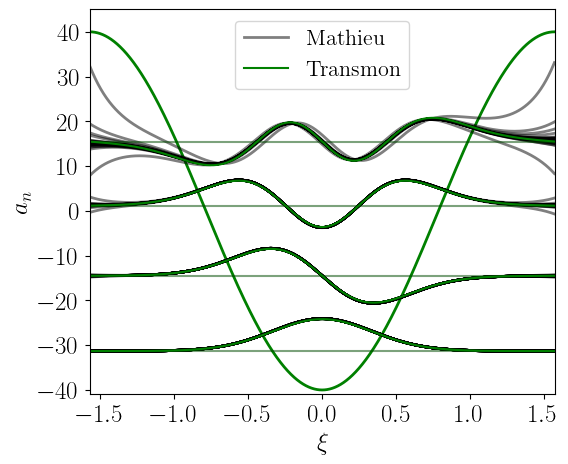

In [25]:
# Parameters for the transmon
qtest = 20
E_C = 1.0  # Charging energy
E_J = 2*qtest*E_C  # Josephson energy
num_points = 2000  # Number of grid points for φ
phi_max = np.pi  # Range for φ

# Discretize the φ range
phi = np.linspace(-phi_max, phi_max, num_points)
dphi = phi[1] - phi[0]

# Potential term: V(phi) = -E_J * cos(phi)
V = -E_J * np.cos(phi)

# Kinetic term: T = -4 * E_C * d^2/dphi^2
kinetic = -4 * E_C / dphi**2
diagonal_kinetic = np.full(num_points, -2 * kinetic)
off_diagonal_kinetic = np.full(num_points - 1, kinetic)
T = diags([diagonal_kinetic, off_diagonal_kinetic, off_diagonal_kinetic], [0, -1, 1])

# Full Hamiltonian: H = T + V
H = T + diags([V], [0])

# Solve for eigenvalues and eigenvectors
eigenvalues, eigenvectors = eigh(H.toarray())
eigenvalues = eigenvalues[:5]  # Only take the first 10 eigenvalues
eigenvectors = eigenvectors[:, :5]
print(eigenvalues)


# Calculate characteristic values (eigenvalues) for the first few Mathieu functions
n_values = range(5)  # Compute for n = 0, 1, 2, 3
eig_even = [E_C * mathieu_a(n, qtest) for n in n_values]
eig_odd = [E_C * mathieu_b(n+1, qtest) for n in n_values]
print(eig_even,eig_odd)

amp = 140
# Plot the potential and eigenfunctions
fonty = 18
fig3 = plt.figure(figsize=(6, 5))
plt.rc('text', usetex=True)

alphr = 0.2
plt.plot(phi/2, -E_J * np.cos(phi),'g-',linewidth=2)
#plt.plot(phi/2, -2*qtest+4*qtest*(phi/2)**2,'r-',linewidth=2,alpha=alphr)

for ii in range(20):
    plt.plot(listcell[0:-1:1]-np.pi/2.,0.0136*np.real(MAtFloq0A[ii,:])/np.real(coeff0A*rho0A**ii) + eigenvalues[0],'k',linewidth=2,alpha=0.5)
    plt.plot(listcell[0:-1:1]-np.pi/2.,0.0136*np.real(MAtFloq0B[ii,:])/np.real(coeff0B*rho0B**ii) + eigenvalues[0],'k',linewidth=2,alpha=0.5)
    plt.plot(listcell[0:-1:1]-np.pi/2.,0.114*np.real(MAtFloq1A[ii,:])/np.real(coeff1A*rho1A**ii) + eigenvalues[1],'k',linewidth=2,alpha=0.5)
    plt.plot(listcell[0:-1:1]-np.pi/2.,0.114*np.real(MAtFloq1B[ii,:])/np.real(coeff1B*rho1B**ii) + eigenvalues[1],'k',linewidth=2,alpha=0.5)
    plt.plot(listcell[0:-1:1]-np.pi/2.,0.65*np.real(MAtFloq2A[ii,:])/np.real(coeff2A*rho2A**ii) + eigenvalues[2],'k',linewidth=2,alpha=0.5)
    plt.plot(listcell[0:-1:1]-np.pi/2.,0.65*np.real(MAtFloq2B[ii,:])/np.real(coeff2B*rho2B**ii) + eigenvalues[2],'k',linewidth=2,alpha=0.5)
    plt.plot(listcell[0:-1:1]-np.pi/2.,-2.7*np.real(MAtFloq3A[ii,:])/np.real(coeff3A*rho3A**ii) + eigenvalues[3],'k',linewidth=2,alpha=0.5)
    plt.plot(listcell[0:-1:1]-np.pi/2.,-2.7*np.real(MAtFloq3B[ii,:])/np.real(coeff3B*rho3B**ii) + eigenvalues[3],'k',linewidth=2,alpha=0.5)
        
plt.plot(np.NaN,np.NaN,'k',linewidth=2,alpha=0.5,label=r'$\mathrm{Mathieu}$')

for i in range(4):
    #aHQOcorrec = 2*(i+0.5)*np.sqrt(4*qtest)-2*qtest-(i*(i+1)/2+0.25)
    aHQOcorrec = 2*(i+0.5)*np.sqrt(4*qtest)-2*qtest
    #plt.plot([-np.pi,np.pi], [aHQOcorrec,aHQOcorrec], 'r-',alpha=alphr)
    #plt.plot([-np.pi,np.pi], [eigenvalues[i],eigenvalues[i]], 'g:')
    plt.plot(np.array([-phi_max,phi_max]),np.array([eig_even[i],eig_even[i]]),'k-',alpha=0.3) 
    plt.plot(np.array([-phi_max,phi_max]),np.array([eig_odd[i],eig_odd[i]]),'g-',alpha=0.3)
    plt.fill_betweenx(np.array([eig_even[i],eig_odd[i]]),np.array([-phi_max,-phi_max]), np.array([phi_max,phi_max]), facecolor='k',alpha=0.5)
    if i < 4:
        plt.plot(phi/2, eigenvectors[:, i]*amp + eigenvalues[i],'g-')
    
plt.plot([np.NaN,np.NaN], [np.NaN,np.NaN], 'g-',label=r'$\mathrm{Transmon}$')
#plt.plot([np.NaN,np.NaN], [np.NaN,np.NaN], 'r-',label=r'$\mathrm{QHO}$',alpha=alphr+0.2)
plt.fill_betweenx(np.array([100,200]),np.array([-phi_max,-phi_max]), np.array([phi_max,phi_max]), 
                  facecolor='k',alpha=0.5)

plt.xticks(size=fonty)
plt.yticks(size=fonty)
plt.xlim(-phi_max/2, phi_max/2)
plt.ylim(-2*qtest-1,2*qtest+5)
#plt.ylim(-2.5,-2)
#plt.ylim(7.5,8)
plt.xlabel(r'$\xi$', fontsize=fonty)
plt.ylabel('$a_n$', fontsize=fonty)
plt.legend(fontsize=fonty-2, loc='best')
plt.show()

fig3.savefig('Transmon_schrodinger_approx_comparison.png', format='png', dpi=1000,bbox_inches='tight')



#fig4 = plt.figure(figsize=(10, 6))
#plt.plot(phi, eigenvectors[:, 0]*30, label=f"Eigenstate {0}")

## By Arnaud Lazarus - 06/13/2026